## Notebook 5: Vegetation

In [97]:
import os
os.environ["CITY"] = "genova"   # pick the city here

In [98]:
# Generic bootstrap 
from pathlib import Path
import os, sys

def _find_root():
    start = Path.cwd()
    for cand in [start, *start.parents]:
        if (cand/"cityheat").is_dir() and (cand/"configs").is_dir():
            return cand
    raise RuntimeError("Repo root not found.")
ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from cityheat.nbsetup import bootstrap
from cityheat.paths import make_P, ensure_out

# Choose city here
SLUG = globals().get("SLUG", os.environ.get("CITY", "rome")).lower()

C    = bootstrap(SLUG)      # reads configs/<slug>.yml and syncs that city only if wanted
CFG  = C["CFG"]; CITY = C["CITY"]
BASE = C["BASE"]; OUT = C["OUT"]; INT = C["INT"]

P    = make_P(BASE)         # read-only path helper
OUTP = ensure_out(OUT)      # write-safe path helper
print(f"→ City: {CITY}  |  BASE={BASE}  OUT={OUT}  INT={INT}")

→ City: genova  |  BASE=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova  OUT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova  INT=/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim


In [99]:
# city config + file paths from YAML 
cfg = C.get("cfg", {})                      # full YAML for the selected city
SLUG = cfg.get("slug", SLUG).lower()        
CITY = cfg.get("city_name", CITY)

paths    = cfg.get("files", {})             # {gvi_csv, lcz_candidates, cooling_coeffs_csv, ...}
osm_cfg  = cfg.get("osm", {})               # OSM settings used later in NB5
trees_cfg = cfg.get("trees", {})            # TARGET/CAP for NB5
urbclim   = cfg.get("urbclim", {})          # UrbClim folder/settings for NB5

lcz_candidates = [P(p) for p in paths.get("lcz_candidates", [])]
gvi_path = P(paths.get("gvi_csv", ""))

# FUA geopackage written in NB2 
fua_gpkg = Path(paths.get("fua_gpkg", f"{OUT}/{SLUG}_fua.gpkg"))

cool_csv = P(paths.get("cooling_coeffs_csv", ""))

# checks
print("SLUG/CITY:", SLUG, CITY)
print("GVI CSV:  ", gvi_path)
print("LCZ cand: ", [str(p) for p in lcz_candidates])
print("FUA GPKG: ", fua_gpkg)
print("Cooling CSV:", cool_csv)

SLUG/CITY: genova Genova
GVI CSV:   /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/gviGenova/gvi_Genova.csv
LCZ cand:  ['/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_filter_v3.tif', '/Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/LCZ/lcz_v3.tif']
FUA GPKG:  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_fua.gpkg
Cooling CSV: /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/data/genova/CoolingEff/outer_2_wbgt_max.csv


**Loading what we need from previous notebooks**

In [100]:
from pathlib import Path
import json, numpy as np, geopandas as gpd, rasterio as rio

# Paths from NB2
tmpl_path = INT / "template_ref.tif"
mask_tif  = INT / "city_mask.tif"
fua_gp    = OUT / f"{SLUG}_fua.gpkg"

age_npz = INT / f"age_on_ref_{SLUG}.npz"
if not age_npz.exists():
    age_npz = INT / "age_on_ref.npz"

pop_npz = INT / f"pop_on_ref_{SLUG}.npz"
if not pop_npz.exists():
    pop_npz = INT / "pop_on_ref.npz"

# Template/meta + mask
with rio.open(tmpl_path) as src:
    ref_meta = src.meta.copy()
    HGT, WDT = ref_meta["height"], ref_meta["width"]

with rio.open(mask_tif) as src:
    CITY_MASK = src.read(1).astype(bool)

# loading age/pop arrays 
agez = np.load(age_npz)
age_on_ref = {"<15": agez["lt15"], "15-64": agez["a15_64"], "65+": agez["g65"]}
pop_on_ref = np.load(pop_npz)["pop"]

# FUA
if not fua_gp.exists():
    raise FileNotFoundError(f"Missing FUA GeoPackage: {fua_gp} — re-run Notebook 2 for {CITY}.")
fua = gpd.read_file(fua_gp, layer="fua")
fua_4326 = fua.to_crs("EPSG:4326")

# Footprint
ref_data = np.where(CITY_MASK, 0.0, np.nan)
HAZ_MASK = np.isfinite(ref_data)

print("WBGT grid:", (HGT, WDT), "| CRS:", ref_meta["crs"])
print("CITY_MASK true pixels:", int(CITY_MASK.sum()))

WBGT grid: (191, 291) | CRS: EPSG:4326
CITY_MASK true pixels: 24823


In [101]:
import numpy as np
import rasterio as rio
from rasterio.enums import Resampling
from rasterio.vrt import WarpedVRT
from rasterio import features
from scipy import ndimage as ndi

# FUA mask on the reference grid 
fua_ref = fua.to_crs(ref_meta["crs"])
fua_mask_ref = features.rasterize(
    [(geom, 1) for geom in fua_ref.geometry],
    out_shape=(ref_meta["height"], ref_meta["width"]),
    transform=ref_meta["transform"], fill=0, dtype="uint8"
).astype(bool)

# LCZ path from Drive
p_LCZ = P("LCZ")
lcz_candidates = [p_LCZ / "lcz_filter_v3.tif", p_LCZ / "lcz_v3.tif"]
lcz_path = next((p for p in lcz_candidates if p.exists()), None)
if lcz_path is None:
    raise FileNotFoundError(f"No LCZ raster found under {p_LCZ}. Expected one of: {', '.join(map(str, lcz_candidates))}")

print("Using LCZ:", lcz_path.name)

# LCZ -> ref grid 
def lcz_to_ref_stream(path, ref_meta):
    with rio.open(path) as src:
        src_nod = src.nodata if src.nodata is not None else 0  # LCZ uses 0 as nodata
        vrt_opts = dict(
            crs=ref_meta["crs"],
            transform=ref_meta["transform"],
            width=ref_meta["width"],
            height=ref_meta["height"],
            resampling=Resampling.nearest,
            src_nodata=src_nod,
            nodata=np.nan,              # output NaN where LCZ is nodata
        )
        with WarpedVRT(src, **vrt_opts) as vrt:
            dst = vrt.read(1, out_dtype="float32")  # only the Rome window at ref resolution
    return dst

lcz_reproj = lcz_to_ref_stream(lcz_path, ref_meta)

# masking to FUA on the reference grid (stay NaN outside city)
lcz_on_ref = np.where(fua_mask_ref, lcz_reproj, np.nan)

# filling LCZ holes only inside hazard + keep 0 strictly outside hazard
haz_mask = np.isfinite(ref_data)                    # WBGT footprint on ref grid
work = np.where(haz_mask, lcz_on_ref, np.nan)       # ignore outside-hazard during fill
missing_inside = np.isnan(work) & haz_mask

if missing_inside.any():
    valid = (~np.isnan(work)) & haz_mask
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    work[missing_inside] = work[iy[missing_inside], ix[missing_inside]]

lcz_on_ref = np.where(haz_mask, work, 0).astype("int16")
assert ((lcz_on_ref > 0) | (~haz_mask)).all()

Using LCZ: lcz_filter_v3.tif


## GVI

In [102]:
import pandas as pd

# GVI path from Drive
files_cfg = (cfg or {}).get("files", {})
gvi_rel = files_cfg.get("gvi_csv")
if not gvi_rel:
    raise KeyError("Missing 'files.gvi_csv' in YAML config.")

from shapely.geometry import Point

gvi_df = pd.read_csv(gvi_path)

# making sure we have x, y, gvi columns 
colmap = {c.lower(): c for c in gvi_df.columns}
need = {"x","y","gvi"}
missing = need - set(colmap)
if missing:
    raise ValueError(f"GVI CSV must have columns {need}, got {list(gvi_df.columns)}")

gvi_gdf = gpd.GeoDataFrame(
    gvi_df.rename(columns={colmap["x"]:"x", colmap["y"]:"y", colmap["gvi"]:"gvi"}),
    geometry=gpd.points_from_xy(gvi_df[colmap["x"]], gvi_df[colmap["y"]]),
    crs="EPSG:4326"
)

# keeping only points within the FUA
gvi_gdf = gvi_gdf.sjoin(fua_4326[["geometry"]], predicate="within", how="inner") \
                 .drop(columns="index_right")

# scale check (0–100 expected)
gvi_min, gvi_med, gvi_max = gvi_gdf["gvi"].min(), gvi_gdf["gvi"].median(), gvi_gdf["gvi"].max()
scale_msg = "0–100" if gvi_max <= 100 + 1e-6 else "unknown"
print(f"GVI scale: {scale_msg} | min={gvi_min:.2f} med={gvi_med:.2f} max={gvi_max:.2f}")
print("Points kept:", len(gvi_gdf), "/", len(gvi_df))

GVI scale: 0–100 | min=2.30 med=12.08 max=37.56
Points kept: 606 / 606


In [103]:
display(gvi_gdf.head())
print(f"  shape: {gvi_gdf.shape}")

,city,x,y,lcz_filter_v3,gvi,geometry
0,Genoa,8.737716,44.424548,6.0,5.356411,POINT (8.73772 44.42455)
1,Genoa,8.738611,44.424972,6.0,9.910346,POINT (8.73861 44.42497)
2,Genoa,8.742271,44.430237,6.0,6.846162,POINT (8.74227 44.43024)
3,Genoa,8.743505,44.428502,6.0,4.581391,POINT (8.7435 44.4285)
4,Genoa,8.743953,44.434002,11.0,23.749352,POINT (8.74395 44.434)


  shape: (606, 6)


CRS check:
  gvi_gdf.crs = EPSG:4326
  FUA.crs      = EPSG:4326
Points kept inside FUA: 606 / 606  (100.0%)
GVI: min=2.30, median=12.08, max=37.56, NaNs=0
GVI appears to be in 0–100 scale (we could need to divide by 100 later).
Approx duplicate coords (rounded to 1e-6): 0


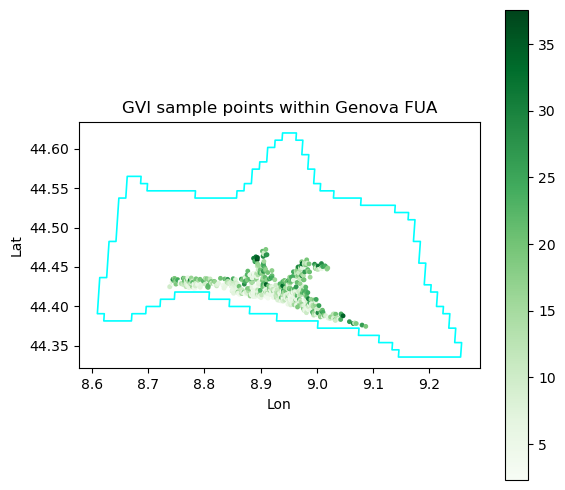

In [104]:
# Check 
import numpy as np
import matplotlib.pyplot as plt

print("CRS check:")
print("  gvi_gdf.crs =", gvi_gdf.crs)
print("  FUA.crs      =", fua.to_crs("EPSG:4326").crs)

# counting points before/after the clip
n_raw  = len(pd.read_csv(gvi_path))   # using resolved path from YAML
n_keep = len(gvi_gdf)
print(f"Points kept inside FUA: {n_keep} / {n_raw}  ({100*n_keep/n_raw:.1f}%)")

# how many nas, min/median/max value of gvi 
na_gvi = gvi_gdf["gvi"].isna().sum()
gvi_min, gvi_p50, gvi_max = gvi_gdf["gvi"].min(), gvi_gdf["gvi"].median(), gvi_gdf["gvi"].max()
print(f"GVI: min={gvi_min:.2f}, median={gvi_p50:.2f}, max={gvi_max:.2f}, NaNs={na_gvi}")

# detecting the scale of the gvi (0–1 vs 0–100) 
# (just a way to do it in general, we knew already since we inspected the dataset before)
if gvi_max <= 1.5:
    print("GVI appears to be in 0–1 scale.")
elif gvi_max <= 100 + 1e-6:
    print("GVI appears to be in 0–100 scale (we could need to divide by 100 later).")
else:
    print("WARNING: GVI scale looks unusual")

# any obvious duplicates (same lon/lat)
dups = (gvi_gdf
        .assign(lon=lambda d: d.geometry.x.round(6),
                lat=lambda d: d.geometry.y.round(6))
        .duplicated(subset=["lon","lat"])
        .sum())
print("Approx duplicate coords (rounded to 1e-6):", int(dups))

# quick map
fua_4326 = fua.to_crs("EPSG:4326")
ax = fua_4326.plot(edgecolor="cyan", facecolor="none", linewidth=1.2, figsize=(6,5))
gvi_gdf.plot(ax=ax, markersize=6, column="gvi", cmap="Greens", legend=True)
ax.set_title(f"GVI sample points within {CITY} FUA")  # <- use CITY
ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
plt.tight_layout(); plt.show()

# if many points were dropped, boundary-inclusive join
if n_keep < 0.5 * n_raw:
    print("\nMany points were dropped. Try a boundary-inclusive join:")
    print("gvi_gdf = gvi_gdf.sjoin(fua_4326[['geometry']], predicate='intersects', how='inner').drop(columns='index_right')")

**Building Municipi (OSM), dissolving to 15 units + “Fuori Municipi”**

In [105]:
# City-agnostic OSM regions → `regions` (Municipi/Barrios/Districts) 

import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox

# YAML
osm_cfg     = (cfg or {}).get("osm", {})
query       = osm_cfg.get("query", CITY)                         
levels      = [str(x) for x in osm_cfg.get("admin_levels", [10,8,7])]
b_tag       = osm_cfg.get("boundary_tag", "administrative")
keep_out    = bool(osm_cfg.get("keep_outside_bucket", True))
exclude_ids = set(int(i) for i in osm_cfg.get("exclude_region_ids", []))

# OSMnx settings
ox.settings.use_cache = True
ox.settings.log_console = False

# City polygon
city_poly = ox.geocode_to_gdf(query).to_crs("EPSG:4326").geometry.iloc[0]

# pull all 'administrative' features, then pick first admin_level that exists
raw = ox.features_from_polygon(city_poly, tags={"boundary": b_tag})
raw = raw[raw.geometry.type.isin(["Polygon", "MultiPolygon"])].copy().to_crs("EPSG:4326")
for col in ("admin_level", "boundary", "name", "name:it", "short_name", "ref"):
    if col not in raw.columns:
        raw[col] = None

picked = None
sel_level = None
for level in levels:
    cand = raw[(raw["boundary"] == b_tag) & (raw["admin_level"].astype(str) == level)]
    if not cand.empty:
        picked = cand.copy()
        sel_level = level
        break
if picked is None:
    raise RuntimeError(
        f"No OSM '{b_tag}' polygons with admin_level in {levels} for '{query}'. "
        "Adjust cfg.osm.admin_levels or cfg.osm.query."
    )

# clipping to FUA footprint (already WGS84)
picked = gpd.overlay(
    picked[["geometry","name","name:it","short_name","ref"]].reset_index(drop=True),
    fua_4326[["geometry"]],
    how="intersection"
)

# readable names
def _pick_name(row):
    for k in ("name:it", "name", "short_name", "ref"):
        v = row.get(k)
        if isinstance(v, str) and v.strip():
            return v.strip()
    return "Region"

picked["muni_name"] = picked.apply(_pick_name, axis=1)

# one polygon per region
muni = picked.dissolve(by="muni_name", as_index=False, aggfunc="first").reset_index(drop=True)

# stable integer IDs
# If the names end with Roman numerals (Rome), map to integers; else sequential.
roman_map = {"I":1,"II":2,"III":3,"IV":4,"V":5,"VI":6,"VII":7,"VIII":8,
             "IX":9,"X":10,"XI":11,"XII":12,"XIII":13,"XIV":14,"XV":15}
rom = muni["muni_name"].str.extract(r'([IVXLCDM]+)\s*$', expand=False)
ids = rom.map(roman_map)

if ids.notna().all():
    muni["muni_id"] = ids.astype(int)
else:
    muni = muni.reset_index(drop=True)
    muni["muni_id"] = muni.index + 1  

# optional manual exclusions from YAML (example: Rome’s Ostia=10)
if exclude_ids:
    before = len(muni)
    muni = muni[~muni["muni_id"].isin(exclude_ids)].copy()
    muni = muni.sort_values("muni_id").reset_index(drop=True)
    print(f"Excluded IDs {sorted(exclude_ids)} → {before} → {len(muni)} regions.")

print(f"OSM admin_level={sel_level} → {len(muni)} regions. Examples:",
      sorted(muni["muni_name"].unique())[:6])

# “Outside FUA” bucket (ID 0) (optional)
regions_parts = [muni[["muni_id","muni_name","geometry"]]]
if keep_out:
    gseries = muni.geometry
    geom_union = gseries.union_all() if hasattr(gseries, "union_all") else gseries.unary_union
    muni_union = gpd.GeoDataFrame(geometry=[geom_union], crs="EPSG:4326")
    outside = gpd.overlay(fua_4326[["geometry"]], muni_union, how="difference")
    if not outside.empty:
        outside = outside.set_crs("EPSG:4326")
        outside["muni_id"] = 0
        outside["muni_name"] = "Outside regions (FUA)"
        regions_parts.append(outside[["muni_id","muni_name","geometry"]])

# final layer
regions = pd.concat(regions_parts, ignore_index=True).set_crs("EPSG:4326")
print("Regions ready. IDs:", regions["muni_id"].tolist())

OSM admin_level=10 → 9 regions. Examples: ['Bassa Val Bisagno', 'Centro Est', 'Centro Ovest', 'Levante', 'Media Val Bisagno', 'Medio Levante']
Regions ready. IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9, 0]


,city,x,y,lcz_filter_v3,gvi,geometry,muni_id,muni_name
0,Genoa,8.737716,44.424548,6.0,5.356411,POINT (8.73772 44.42455),8,Ponente
1,Genoa,8.738611,44.424972,6.0,9.910346,POINT (8.73861 44.42497),8,Ponente
2,Genoa,8.742271,44.430237,6.0,6.846162,POINT (8.74227 44.43024),8,Ponente
3,Genoa,8.743505,44.428502,6.0,4.581391,POINT (8.7435 44.4285),8,Ponente
4,Genoa,8.743953,44.434002,11.0,23.749352,POINT (8.74395 44.434),8,Ponente


Points in outside bucket (ID=0): 7
Unmatched points (outside FUA / geometry issue): 0


,muni_id,muni_name,count,mean,median,p10,p90,gvi_mean_0_1,gvi_median_0_1,area_km2,pts_per_km2
0,0,Outside regions (FUA),7,17.973093,18.784375,10.071444,27.575442,0.179731,0.187844,618.496319,0.011318
1,1,Bassa Val Bisagno,59,11.963060,9.432865,4.146562,22.379494,0.119631,0.094329,7.937521,7.433051
2,2,Centro Est,64,10.930563,9.888310,5.073474,19.317897,0.109306,0.098883,7.723666,8.286220
3,3,Centro Ovest,47,9.244785,6.513252,3.559001,17.452752,0.092448,0.065133,7.689732,6.112047
4,4,Levante,68,15.595548,15.641773,6.420908,24.933548,0.155955,0.156418,36.566507,1.859625
5,5,Media Val Bisagno,97,17.780418,18.250509,8.655848,27.052109,0.177804,0.182505,41.803647,2.320372
6,6,Medio Levante,31,10.462763,8.494739,4.047695,19.162367,0.104628,0.084947,6.094669,5.086412
7,7,Medio Ponente,69,11.766265,9.167718,5.827215,21.450940,0.117663,0.091677,22.301023,3.094028
8,8,Ponente,95,13.134163,11.311172,4.504149,22.333830,0.131342,0.113112,77.409215,1.227244
9,9,Val Polcevera,69,17.561629,18.435132,6.142965,27.852883,0.175616,0.184351,33.168685,2.080275


Min samples (excluding outside=0): 31


Text(19.847222222222214, 0.5, 'Lat')

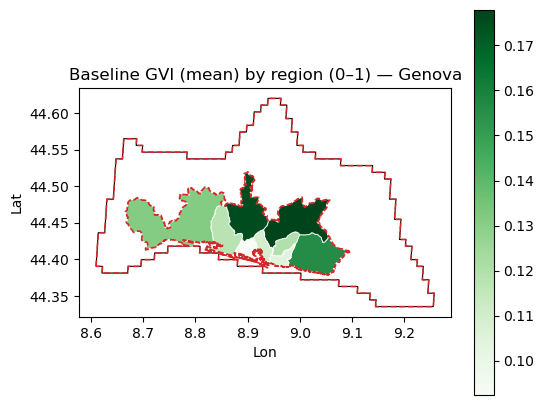

In [106]:
# City-agnostic: GVI and regions summary +  map 

assert {"muni_id","muni_name","geometry"}.issubset(regions.columns), "regions layer missing required columns"

# spatialjoin: tagging each GVI point with a region
gvi_in_regions = gvi_gdf.sjoin(
    regions[["muni_id","muni_name","geometry"]],
    predicate="within", how="left"
).drop(columns="index_right")

display(gvi_in_regions.head())

# diagnostics: outside bucket (ID 0) and unmatched
has_outside = (regions["muni_id"] == 0).any()
n_outside   = int((gvi_in_regions["muni_id"] == 0).sum()) if has_outside else 0
n_unmatched = int(gvi_in_regions["muni_id"].isna().sum())
print(f"Points in outside bucket (ID=0): {n_outside}")
print(f"Unmatched points (outside FUA / geometry issue): {n_unmatched}")

# aggregating by region (mean/median/quantiles), keeping both 0–100 and 0–1 scales
reg_gvi = (gvi_in_regions
           .groupby(["muni_id","muni_name"], as_index=False)["gvi"]
           .agg(count="count",
                mean="mean",
                median="median",
                p10=lambda s: s.quantile(0.10),
                p90=lambda s: s.quantile(0.90)))
reg_gvi["gvi_mean_0_1"]   = reg_gvi["mean"]   / 100.0
reg_gvi["gvi_median_0_1"] = reg_gvi["median"] / 100.0

# area (km²) + sample density — using an automatic local metric CRS
metric_crs = regions.estimate_utm_crs() or "EPSG:3857"
areas = regions.to_crs(metric_crs)[["muni_id","geometry"]].copy()
areas["area_km2"] = areas.geometry.area / 1e6

reg_gvi = (reg_gvi
           .merge(areas[["muni_id","area_km2"]], on="muni_id", how="left")
           .assign(pts_per_km2=lambda d: d["count"] / d["area_km2"]))

# sorting + head 
reg_gvi = reg_gvi.sort_values(["muni_id","muni_name"]).reset_index(drop=True)
display(reg_gvi)

if (reg_gvi["muni_id"] > 0).any():
    print("Min samples (excluding outside=0):",
          int(reg_gvi.loc[reg_gvi["muni_id"]>0, "count"].min()))

# Map: region means (exclude outside bucket)
muni_only = regions.loc[regions["muni_id"] > 0]
muni_gvi  = muni_only.merge(reg_gvi, on=["muni_id","muni_name"], how="left")

ax = fua_4326.plot(edgecolor="k", facecolor="none", linewidth=0.8, figsize=(6,5))
muni_gvi.plot(ax=ax, column="gvi_mean_0_1", cmap="Greens",
              legend=True, edgecolor="white", linewidth=0.6)
if has_outside:
    regions.loc[regions["muni_id"] == 0].plot(
        ax=ax, facecolor="none", edgecolor="tab:red", linewidth=1.2, linestyle="--"
    )
ax.set_title(f"Baseline GVI (mean) by region (0–1) — {CITY}")
ax.set_xlabel("Lon"); ax.set_ylabel("Lat")

This is only informative, a descriptive analysis, after we need to do GVI to WBGT grid

In [107]:
# Summary of region-level GVI (means), excluding outside bucket (muni_id == 0 if present)
has_outside = (reg_gvi["muni_id"] == 0).any()
mask = reg_gvi["muni_id"] != 0 if has_outside else reg_gvi["muni_id"].notna()

s100 = reg_gvi.loc[mask, "mean"].dropna()          # 0–100 scale
s01  = reg_gvi.loc[mask, "gvi_mean_0_1"].dropna()  # 0–1 scale

def summarize(s):
    return pd.Series({
        "min": s.min(),
        "Q1": s.quantile(0.25),
        "median": s.median(),
        "mean": s.mean(),
        "Q3": s.quantile(0.75),
        "max": s.max(),
        "sd":  s.std(ddof=1)
    })

summary_table = pd.concat([summarize(s100), summarize(s01)], axis=1)
summary_table.columns = ["GVI (0–100)", "GVI (0–1)"]
display(summary_table.round(2))

,GVI (0–100),GVI (0–1)
min,9.24,0.09
Q1,10.93,0.11
median,11.96,0.12
mean,13.16,0.13
Q3,15.60,0.16
max,17.78,0.18
sd,3.11,0.03


In [108]:
# City-agnostic filtering 
osm_cfg = (cfg or {}).get("osm", {})
MIN_SAMPLES = int(osm_cfg.get("min_samples", 10))
EXCLUDE_IDS = set(int(x) for x in osm_cfg.get("exclude_region_ids", []))

mask = (
    reg_gvi["muni_id"].notna()
    & (~reg_gvi["muni_id"].isin({0} | EXCLUDE_IDS))
    & (reg_gvi["count"] >= MIN_SAMPLES)
)

reg_gvi_ok = reg_gvi.loc[mask, ["muni_id","muni_name","gvi_mean_0_1"]].copy()
muni_ok    = muni[muni["muni_id"].isin(reg_gvi_ok["muni_id"])]

In [109]:
# Municipi and LCZ to WBGT ref grid
import numpy as np
import rasterio
from rasterio.mask import mask as rio_mask
from rasterio.warp import reproject
from rasterio.enums import Resampling
import geopandas as gpd
from pathlib import Path

# function to open raster, clip it to FUA, return float array with nas outside FUA
def read_and_mask_to_fua(raster_path: Path, fua_gdf: gpd.GeoDataFrame):
    with rasterio.open(raster_path) as src:
        fua_in_raster_crs = fua_gdf.to_crs(src.crs)
        geoms = [g for g in fua_in_raster_crs.geometry if g is not None]
        if not geoms:
            raise ValueError("FUA geometry is empty or invalid.")
        out_ma, out_transform = rio_mask(src, geoms, crop=True, filled=False)

        data = out_ma[0].astype("float32")
        m = np.ma.getmaskarray(out_ma[0])
        data[m] = np.nan

        nod = src.nodata if src.nodata is not None else 0.0
        data[data == nod] = np.nan

        out_meta = src.meta.copy()
        out_meta.update({
            "height": data.shape[0],
            "width":  data.shape[1],
            "transform": out_transform,
            "dtype": "float32"
        })
        return data, out_transform, src.crs, out_meta

# this takes other raster and put it on the exact same grid as ref (as before)
def ensure_on_reference_grid_nearest(src_path: Path, ref_meta, ref_data_shape, fua_gdf: gpd.GeoDataFrame):
    """clipping src raster to FUA and resampling to the reference grid, preserving NaNs."""
    src_data, src_transform, src_crs, src_meta = read_and_mask_to_fua(src_path, fua_gdf)

    same_grid = (
        (src_meta["crs"] == ref_meta["crs"]) and
        (src_meta["transform"] == ref_meta["transform"]) and
        (src_data.shape == ref_data_shape)
    )
    if same_grid:
        return src_data, ref_meta

    dst = np.full(ref_data_shape, np.nan, dtype="float32")
    reproject(
        source=src_data,
        destination=dst,
        src_transform=src_meta["transform"],
        src_crs=src_meta["crs"],
        dst_transform=ref_meta["transform"],
        dst_crs=ref_meta["crs"],
        resampling=Resampling.nearest,
        src_nodata=0.0,      # careful!! 
        dst_nodata=np.nan,
    )
    return dst, ref_meta

In [110]:
# applying the two functions we defined
# Municipi to WBGT grid
muni_ref = muni.to_crs(ref_meta["crs"])
shapes = [(geom, int(mid)) for geom, mid in zip(muni_ref.geometry, muni_ref["muni_id"])]
muni_on_ref = rasterio.features.rasterize(
    shapes=shapes, out_shape=ref_data.shape, transform=ref_meta["transform"],
    fill=0, dtype="int32"
)

In [111]:
print("muni_on_ref:", muni_on_ref.shape, "unique IDs:", np.unique(muni_on_ref).size)

muni_on_ref: (191, 291) unique IDs: 10


In [112]:
# new masks
MUNI_PIX = CITY_MASK & (muni_on_ref > 0) # second mask for all the Municipi level aggregation

In [113]:
import numpy as np
from scipy import ndimage as ndi

# using HAZ_MASK 
haz_mask = np.isfinite(ref_data)

# filling only inside hazard
work = np.where(haz_mask, lcz_on_ref, np.nan)
missing_inside = np.isnan(work) & haz_mask

if missing_inside.any():
    valid = (~np.isnan(work)) & haz_mask
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    work[missing_inside] = work[iy[missing_inside], ix[missing_inside]]

# check
lcz_on_ref = np.where(haz_mask, work, 0).astype("int16")
assert ((lcz_on_ref > 0) | (~haz_mask)).all(), "Still have LCZ==0 inside hazard—check inputs."
print("OK: LCZ now defined for all hazard pixels.")

OK: LCZ now defined for all hazard pixels.


**GVI to WBGT grid (cell means; nearest fill)**

Everything on WBGT grid. We map points to cells, average if multiple points fall in the same cell, and fill empty cells by nearest neighbor so every hazard pixel has a GVI.

In [114]:
import numpy as np
from rasterio.transform import rowcol
from scipy import ndimage as ndi

# ensuring CRS match (ref grid is EPSG:4326)
if str(gvi_gdf.crs) != str(ref_meta["crs"]):
    gvi_xy = gvi_gdf.to_crs(ref_meta["crs"]).geometry
else:
    gvi_xy = gvi_gdf.geometry

# mapping each GVI point to WBGT ref grid
rows, cols = rowcol(ref_meta["transform"],
                    gvi_xy.x.values,
                    gvi_xy.y.values,
                    op=np.floor)
rows = rows.astype(int); cols = cols.astype(int)

h, w = HGT, WDT
inside = (rows >= 0) & (rows < h) & (cols >= 0) & (cols < w)
rows, cols = rows[inside], cols[inside]
vals = (gvi_gdf.loc[inside, "gvi"].to_numpy(float) / 100.0)  # 0–1 scale

# binning by cell: mean of all samples in each cell
sum_grid = np.zeros((h, w), float)
cnt_grid = np.zeros((h, w), float)
np.add.at(sum_grid, (rows, cols), vals)
np.add.at(cnt_grid, (rows, cols), 1.0)
gvi_on_ref = np.divide(sum_grid, cnt_grid, out=np.full((h, w), np.nan), where=cnt_grid > 0)

# filling missing only within the hazard/city footprint
missing = HAZ_MASK & ~np.isfinite(gvi_on_ref)
if missing.any():
    valid = HAZ_MASK & np.isfinite(gvi_on_ref)
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    gvi_on_ref[missing] = gvi_on_ref[iy[missing], ix[missing]]

# kepping NaN outside hazard 
gvi_on_ref[~HAZ_MASK] = np.nan

print("gvi_on_ref built. Finite share on city mask:",
      float(np.isfinite(gvi_on_ref)[CITY_MASK].mean()))

gvi_on_ref built. Finite share on city mask: 1.0


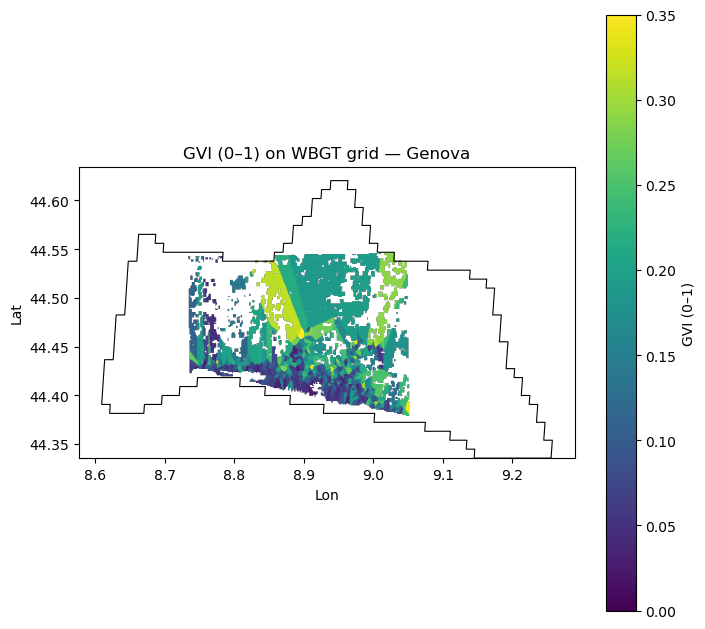

In [115]:
left, bottom, right, top = rio.transform.array_bounds(HGT, WDT, ref_meta["transform"])
extent = (left, right, bottom, top)

plt.figure(figsize=(7.2, 6.4))
im = plt.imshow(gvi_on_ref, origin="upper", extent=extent, vmin=0, vmax=0.35)
cb = plt.colorbar(im); cb.set_label("GVI (0–1)")
fua_4326.boundary.plot(ax=plt.gca(), color="k", lw=0.8)
plt.title(f"GVI (0–1) on WBGT grid — {CITY}")
plt.xlabel("Lon"); plt.ylabel("Lat")
plt.tight_layout(); plt.show()

<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Here we just put the GVI on the WBGT grid. The map shows the pixel values (cell means of points that fall in the cell) with nearest neighbor fill for gaps. 
The plot before was the average of all points inside a whole municipio (before clipping GVI to WBGT grid).
</blockquote>

**Municipi & LCZ on WBGT grid**

In [116]:
# getting rid of Municipi with too small samples points
# City-agnostic filter: drop regions with too few GVI points (and the outside bucket if present)
osm_cfg = (cfg or {}).get("osm", {})
MIN_SAMPLES = int(osm_cfg.get("min_samples", 10))

has_outside = (reg_gvi["muni_id"] == 0).any()
drop_ids = set()

# Outside bucket 
if has_outside:
    drop_ids.add(0)

# Regions with < MIN_SAMPLES samples
weak_ids = set(reg_gvi.loc[reg_gvi["count"] < MIN_SAMPLES, "muni_id"].astype(int))
drop_ids |= weak_ids

keep_mask = (
    reg_gvi["muni_id"].notna()
    & (~reg_gvi["muni_id"].astype(int).isin(drop_ids))
)

reg_gvi_ok = reg_gvi.loc[keep_mask, ["muni_id", "muni_name", "gvi_mean_0_1"]].copy()
muni_ok    = regions.loc[regions["muni_id"].isin(reg_gvi_ok["muni_id"])].copy()

print(f"Dropped for < {MIN_SAMPLES} samples:", sorted(weak_ids))
if has_outside:
    print("Dropped outside bucket (ID=0).")
print("Kept IDs:", sorted(reg_gvi_ok["muni_id"].astype(int).unique().tolist()))

Dropped for < 10 samples: [0]
Dropped outside bucket (ID=0).
Kept IDs: [1, 2, 3, 4, 5, 6, 7, 8, 9]


In [117]:
import rasterio as rio
from rasterio.warp import reproject
from rasterio.enums import Resampling
from rasterio.features import rasterize
from rasterio import features
from rasterio.vrt import WarpedVRT
from rasterio.mask import mask as rio_mask
from scipy import ndimage as ndi
import numpy as np
import pandas as pd
from pathlib import Path

# Regions to label raster (use kept regions only)
M = muni_ok if 'muni_ok' in globals() else muni  # fall back if no filtering
muni_ref_keep = M.to_crs(ref_meta["crs"])
shapes_keep = [(geom, int(mid)) for geom, mid in zip(muni_ref_keep.geometry, muni_ref_keep["muni_id"])]

muni_on_ref = rasterize(
    shapes=shapes_keep,
    out_shape=(HGT, WDT),
    transform=ref_meta["transform"],
    fill=0,                 # 0 = outside any kept region
    dtype="int32"
)

# sanity: raster IDs match kept vector IDs
ids_raster = set(np.unique(muni_on_ref).tolist()) - {0}
ids_vector = set(M["muni_id"].astype(int))
assert ids_raster == ids_vector, f"Raster/vector mismatch: {sorted(ids_raster)} vs {sorted(ids_vector)}"

# LCZ ti reference grid 
lcz_candidates = [P("LCZ") / "lcz_filter_v3.tif", P("LCZ") / "lcz_v3.tif"]
lcz_path = next((p for p in lcz_candidates if Path(p).exists()), None)
assert lcz_path is not None, f"No LCZ raster found. Tried: {', '.join(map(str, lcz_candidates))}"

def lcz_to_ref_stream(path, ref_meta):
    with rio.open(path) as src:
        src_nod = src.nodata if src.nodata is not None else 0  # LCZ uses 0 as nodata
        vrt_opts = dict(
            crs=ref_meta["crs"],
            transform=ref_meta["transform"],
            width=ref_meta["width"],
            height=ref_meta["height"],
            resampling=Resampling.nearest,
            src_nodata=src_nod,
            nodata=np.nan,  # output NaN where LCZ is nodata
        )
        with WarpedVRT(src, **vrt_opts) as vrt:
            return vrt.read(1, out_dtype="float32")

# FUA mask on the reference grid
fua_ref = fua.to_crs(ref_meta["crs"])
fua_mask_ref = features.rasterize(
    [(geom, 1) for geom in fua_ref.geometry],
    out_shape=(ref_meta["height"], ref_meta["width"]),
    transform=ref_meta["transform"],
    fill=0, dtype="uint8"
).astype(bool)

# Reproject + mask to FUA (NaN outside)
lcz_reproj = lcz_to_ref_stream(lcz_path, ref_meta)
lcz_on_ref = np.where(fua_mask_ref, lcz_reproj, np.nan)

# filling LCZ holes only inside hazard, setting 0 strictly outside hazard
haz_mask = np.isfinite(ref_data)  # WBGT footprint on ref grid

work = np.where(haz_mask, lcz_on_ref, np.nan)
missing_inside = np.isnan(work) & haz_mask

if missing_inside.any():
    valid = (~np.isnan(work)) & haz_mask
    _, (iy, ix) = ndi.distance_transform_edt(~valid, return_indices=True)
    work[missing_inside] = work[iy[missing_inside], ix[missing_inside]]

lcz_on_ref = np.where(haz_mask, work, 0).astype("int16")
bad_inside = ((lcz_on_ref <= 0) & haz_mask).sum()
assert bad_inside == 0, f"Still have {bad_inside} LCZ<=0 pixels inside hazard—check inputs."

**Municipio-level GVI (population-weighted)**

Average where people live, not just area

In [118]:
import numpy as np
import pandas as pd

def wmean(x, w):
    m = np.isfinite(x) & np.isfinite(w) & (w > 0)
    return np.average(x[m], weights=w[m]) if m.any() else np.nan

# picking vector layer to define which region IDs are valid (city-agnostic)
M = muni_ok if 'muni_ok' in globals() else (muni if 'muni' in globals() else regions)

# valid (kept) IDs — ignore any outside bucket that isn't in M
valid_ids = np.array(sorted(M["muni_id"].astype(int).unique()))
id_to_pos = {mid: i for i, mid in enumerate(valid_ids)}

# mask pixels that have data and belong to kept IDs
mask = np.isfinite(gvi_on_ref) & np.isfinite(pop_on_ref) & np.isin(muni_on_ref, valid_ids)

x   = gvi_on_ref[mask].astype(float)
w   = pop_on_ref[mask].astype(float)
ids = muni_on_ref[mask].astype(int)

# mapping raw IDs to compact 0..K-1 positions
pos = np.fromiter((id_to_pos[i] for i in ids), count=ids.size, dtype=int)

K   = len(valid_ids)
den = np.bincount(pos, weights=w, minlength=K)
num = np.bincount(pos, weights=w * x, minlength=K)
gvi_pw = np.divide(num, den, out=np.full(K, np.nan, dtype=float), where=den > 0)

reg_gvi_grid = (pd.DataFrame({"muni_id": valid_ids, "gvi_mean_0_1_popw": gvi_pw})
                .merge(M[["muni_id", "muni_name"]], on="muni_id", how="right")
                .sort_values("muni_id")
                .reset_index(drop=True))

display(reg_gvi_grid.head())

,muni_id,gvi_mean_0_1_popw,muni_name
0,1,0.098325,Bassa Val Bisagno
1,2,0.099266,Centro Est
2,3,0.090599,Centro Ovest
3,4,0.148129,Levante
4,5,0.175142,Media Val Bisagno


In [119]:
# City-agnostic summary of population-weighted GVI (exclude any regions not kept in M)
M = muni_ok if 'muni_ok' in globals() else (muni if 'muni' in globals() else regions)

keep_ids = set(M["muni_id"].astype(int).unique())
mask = reg_gvi_grid["muni_id"].isin(keep_ids)

s = reg_gvi_grid.loc[mask, "gvi_mean_0_1_popw"].dropna()

summary = pd.Series({
    "min":    s.min(),
    "Q1":     s.quantile(0.25),
    "median": s.median(),
    "mean":   s.mean(),
    "Q3":     s.quantile(0.75),
    "max":    s.max(),
    "sd":     s.std(ddof=1)
}).round(3)

display(pd.DataFrame(summary, columns=["GVI pop-weighted (0–1)"]))

,GVI pop-weighted (0–1)
min,0.091
Q1,0.099
median,0.104
mean,0.123
Q3,0.148
max,0.179
sd,0.035


In [120]:
# City-agnostic coverage + keep list + baseline table for policy

# point coverage per region (from original spatial join)
gvi_in_regions = gvi_gdf.sjoin(
    gpd.GeoDataFrame(regions[["muni_id","muni_name","geometry"]],
                     geometry="geometry", crs="EPSG:4326"),
    predicate="within", how="left"
)

pt_counts = (gvi_in_regions.groupby("muni_id", as_index=False)["gvi"]
             .size()
             .rename(columns={"size": "count"}))

# region areas (km²) using a local metric CRS
metric_crs = regions.estimate_utm_crs() or "EPSG:3857"
areas = regions.to_crs(metric_crs)[["muni_id", "geometry"]].copy()
areas["area_km2"] = areas.geometry.area / 1e6

# merging counts + areas into the pop-weighted GVI grid summary
coverage = (reg_gvi_grid
            .merge(pt_counts, on="muni_id", how="left")
            .merge(areas[["muni_id", "area_km2"]], on="muni_id", how="left"))

coverage["count"] = coverage["count"].fillna(0).astype(int)
coverage["pts_per_km2"] = coverage["area_km2"].where(coverage["area_km2"] > 0, np.nan)
coverage["pts_per_km2"] = coverage["count"] / coverage["pts_per_km2"]

# thresholds/exclusions from YAML (no city-specific IDs hardcoded)
osm_cfg      = (cfg or {}).get("osm", {})
MIN_SAMPLES  = int(osm_cfg.get("min_samples", 10))
EXCLUDE_IDS  = set(int(x) for x in osm_cfg.get("exclude_region_ids", []))

# dropping outside-bucket (ID=0) if present
drop_ids = set()
if (coverage["muni_id"] == 0).any():
    drop_ids.add(0)

# dropping low-sample regions + any YAML-listed exclusions
low_sample_ids = set(coverage.loc[coverage["count"] < MIN_SAMPLES, "muni_id"].astype(int))
drop_ids |= low_sample_ids | EXCLUDE_IDS

# keeping list and filtered vector layer
keep_mask = ~coverage["muni_id"].astype(int).isin(drop_ids)
keep_ids  = set(coverage.loc[keep_mask, "muni_id"].astype(int))

muni_ok = regions.loc[regions["muni_id"].astype(int).isin(keep_ids)].copy()

# final baseline table for policy (population-weighted GVI)
reg_gvi_ok = (coverage.loc[coverage["muni_id"].astype(int).isin(keep_ids),
                           ["muni_id", "muni_name", "gvi_mean_0_1_popw", "count", "pts_per_km2"]]
                      .rename(columns={"gvi_mean_0_1_popw": "gvi_mean_0_1"})
                      .sort_values("muni_id")
                      .reset_index(drop=True))

display(reg_gvi_ok)

,muni_id,muni_name,gvi_mean_0_1,count,pts_per_km2
0,1,Bassa Val Bisagno,0.098325,59,7.433051
1,2,Centro Est,0.099266,64,8.286220
2,3,Centro Ovest,0.090599,47,6.112047
3,4,Levante,0.148129,68,1.859625
4,5,Media Val Bisagno,0.175142,97,2.320372
5,6,Medio Levante,0.103911,31,5.086412
6,7,Medio Ponente,0.102018,69,3.094028
7,8,Ponente,0.113206,95,1.227244
8,9,Val Polcevera,0.179012,69,2.080275


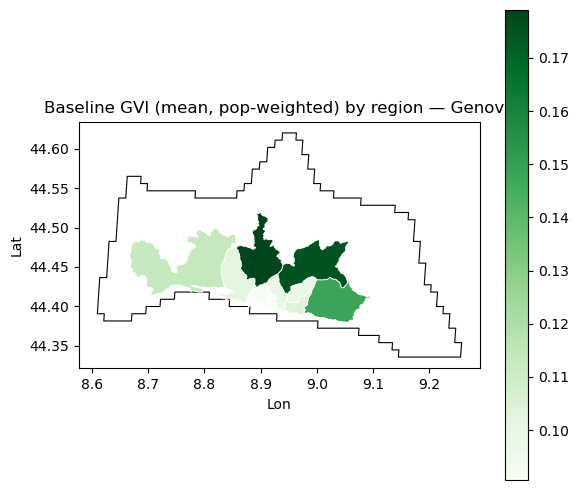

In [121]:
# Map: baseline GVI (mean) by kept regions (WBGT-grid, pop-weighted)

muni_map = (muni_ok[["muni_id","muni_name","geometry"]]
            .merge(reg_gvi_ok[["muni_id","gvi_mean_0_1"]], on="muni_id", how="left")
            .set_crs("EPSG:4326"))

# plot
ax = fua_4326.plot(edgecolor="k", facecolor="none", linewidth=0.8, figsize=(6,5))
muni_map.plot(ax=ax, column="gvi_mean_0_1", cmap="Greens",
              legend=True, edgecolor="white", linewidth=0.6)
ax.set_title(f"Baseline GVI (mean, pop-weighted) by region — {CITY}")
ax.set_xlabel("Lon"); ax.set_ylabel("Lat")
plt.tight_layout(); plt.show()

## Needs-based tree policy (TARGET & CAP)

In [122]:
import numpy as np
import pandas as pd

# City-agnostic target: rounded-up Q3 of pop-weighted GVI 
M = muni_ok if 'muni_ok' in globals() else (muni if 'muni' in globals() else regions)
keep_ids = set(M["muni_id"].astype(int).unique())

s = reg_gvi_grid.loc[reg_gvi_grid["muni_id"].astype(int).isin(keep_ids),
                     "gvi_mean_0_1_popw"].dropna()

def round_up(x, step=0.01):
    return float(np.ceil((x + 1e-12) / step) * step)

q3_raw = float(s.quantile(0.75))
TARGET = round_up(q3_raw, step=0.01)             
TARGET = float(np.clip(TARGET, 0.0, 1.0))       

# CAP: from YAML if present, else default 0.12 (12 percentage points on 0–1 scale)
trees_cfg = (cfg or {}).get("trees", {})
CAP = float(trees_cfg.get("cap_pp", 0.12))

print(f"[Target] Q3(raw)={q3_raw:.3f} → TARGET(ceil to 0.01)={TARGET:.2f} | CAP={CAP:.2f}")

# Needs per kept region (using pop-weighted 0–1 baseline) 
# NOTE: reg_gvi_ok is already filtered to kept regions and uses 'gvi_mean_0_1'
gvi0_by_muni = {int(r.muni_id): float(r.gvi_mean_0_1) for r in reg_gvi_ok.itertuples()}
dGVI_needs   = {mid: min(max(0.0, TARGET - g0), CAP) for mid, g0 in gvi0_by_muni.items()}

# LUT over rasterized regions (muni_on_ref already built on kept regions) 
lut = np.full(int(muni["muni_id"].max()) + 1, np.nan, dtype=float)
for mid, d in dGVI_needs.items():
    lut[int(mid)] = d

MUNI_PIX = HAZ_MASK & (muni_on_ref > 0)
dGVI_map_plot  = np.where(MUNI_PIX, lut[muni_on_ref], np.nan)
dGVI_map_model = np.where(np.isfinite(dGVI_map_plot), dGVI_map_plot, 0.0)

# City diagnostic (population-weighted over kept regions’ pixels) 
w = np.where(MUNI_PIX, pop_on_ref, 0.0)
dGVI_city_pw = (np.nansum(dGVI_map_model * w) / np.nansum(w)) if np.nansum(w) > 0 else np.nan
print(f"[Diag] Citywide ΔGVI (pop-weighted over kept regions): {dGVI_city_pw:.4f}")

[Target] Q3(raw)=0.148 → TARGET(ceil to 0.01)=0.15 | CAP=0.12
[Diag] Citywide ΔGVI (pop-weighted over kept regions): 0.0325


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">
Citywide ΔGVI (pop-weighted over kept regions) is a population-weighted citywide mean of the policy uplift, computed over pixels that lie inside any Municipio and have people. We averaged the per-pixel change in GVI using population in each pixel as the weight. Weights = pop_on_ref, scope = MUNI_PIX (the intersection of Municipi and city footprint, Statistic = sum(change in GVI * pop)/sum(pop). It reflects the change in GVI experienced by the average resident. It's on the 0-1 scale ie *100 on the 1-100 GVI index.
</blockquote>

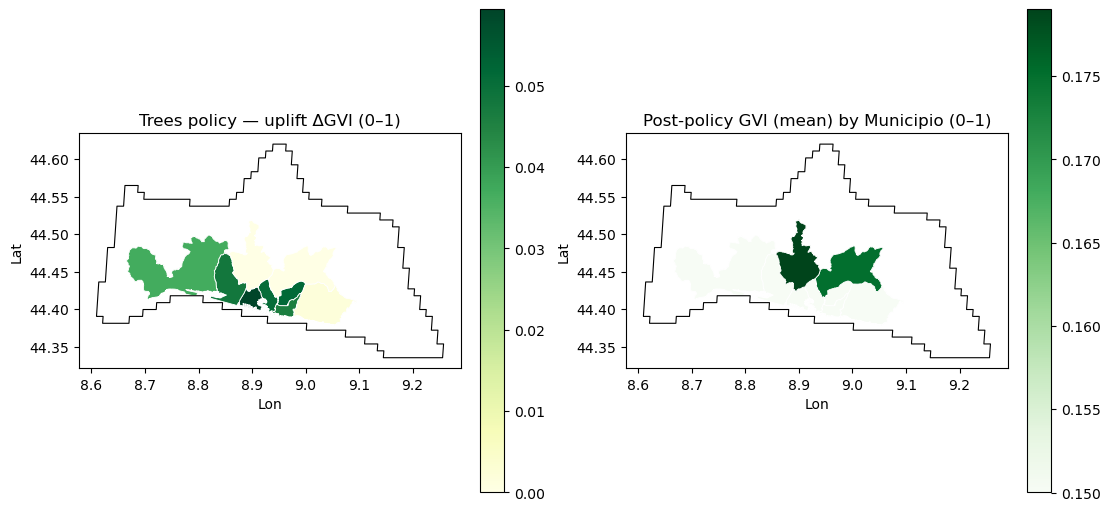

In [123]:
# building plotting frame from kept regions only 
needs_df = pd.DataFrame([{"muni_id": k, "dGVI": v} for k, v in dGVI_needs.items()])
mt = (muni_ok
      .merge(needs_df, on="muni_id", how="left")
      .merge(reg_gvi_ok[["muni_id","muni_name","gvi_mean_0_1"]], on="muni_id", how="left"))
mt["dGVI"]      = mt["dGVI"].fillna(0.0)
mt["gvi_after"] = np.clip(mt["gvi_mean_0_1"] + mt["dGVI"], 0, 1)

def _nudge_for_legend(s: pd.Series, eps=1e-6):
    vmin, vmax = float(s.min()), float(s.max())
    return (vmin, vmax + eps) if np.isclose(vmin, vmax) else (None, None)

dmin, dmax   = _nudge_for_legend(mt["dGVI"])
amin, amax   = _nudge_for_legend(mt["gvi_after"])

fig, ax = plt.subplots(1, 2, figsize=(11,5), constrained_layout=True)

# Left: change in GVI (policy uplift)
fua_4326.boundary.plot(ax=ax[0], color="k", lw=0.8)
mt.plot(ax=ax[0], column="dGVI", cmap="YlGn", legend=True, edgecolor="white", linewidth=0.6,
        vmin=dmin, vmax=dmax)
ax[0].set_title("Trees policy — uplift ΔGVI (0–1)")
ax[0].set_xlabel("Lon"); ax[0].set_ylabel("Lat")

# Right: post-policy mean GVI 
fua_4326.boundary.plot(ax=ax[1], color="k", lw=0.8)
mt.plot(ax=ax[1], column="gvi_after", cmap="Greens", legend=True, edgecolor="white", linewidth=0.6,
        vmin=amin, vmax=amax)
ax[1].set_title("Post-policy GVI (mean) by Municipio (0–1)")
ax[1].set_xlabel("Lon"); ax[1].set_ylabel("Lat")

plt.show()

In [124]:
needs_df = pd.DataFrame([{"muni_id": k, "dGVI": v} for k, v in dGVI_needs.items()])

trees_tbl = (reg_gvi_ok
    .merge(needs_df, on="muni_id", how="left")
    .assign(
        dGVI=lambda d: d["dGVI"].fillna(0.0),
        gvi_after=lambda d: np.clip(d["gvi_mean_0_1"] + d["dGVI"], 0, 1),
        target=lambda d: TARGET,
        cap=lambda d: CAP,
        shortfall_before=lambda d: np.clip(d["target"] - d["gvi_mean_0_1"], 0, None),
        shortfall_after=lambda d: np.clip(d["target"] - d["gvi_after"], 0, None),
        hit_target=lambda d: (d["gvi_after"] + 1e-12) >= d["target"],
        # pretty percent-point columns (optional)
        gvi_mean_pct=lambda d: (d["gvi_mean_0_1"]*100).round(1),
        dGVI_pp=lambda d: (d["dGVI"]*100).round(1),
        gvi_after_pct=lambda d: (d["gvi_after"]*100).round(1),
    )
    .loc[:, ["muni_id","muni_name",
             "gvi_mean_0_1","dGVI","gvi_after",
             "gvi_mean_pct","dGVI_pp","gvi_after_pct",
             "count","pts_per_km2",
             "target","cap","shortfall_before","shortfall_after","hit_target"]]
    .sort_values("muni_id")
)

display(trees_tbl)

,muni_id,muni_name,gvi_mean_0_1,dGVI,gvi_after,gvi_mean_pct,dGVI_pp,gvi_after_pct,count,pts_per_km2,target,cap,shortfall_before,shortfall_after,hit_target
0,1,Bassa Val Bisagno,0.098325,0.051675,0.150000,9.8,5.2,15.0,59,7.433051,0.15,0.12,0.051675,0.0,True
1,2,Centro Est,0.099266,0.050734,0.150000,9.9,5.1,15.0,64,8.286220,0.15,0.12,0.050734,0.0,True
2,3,Centro Ovest,0.090599,0.059401,0.150000,9.1,5.9,15.0,47,6.112047,0.15,0.12,0.059401,0.0,True
3,4,Levante,0.148129,0.001871,0.150000,14.8,0.2,15.0,68,1.859625,0.15,0.12,0.001871,0.0,True
4,5,Media Val Bisagno,0.175142,0.000000,0.175142,17.5,0.0,17.5,97,2.320372,0.15,0.12,0.000000,0.0,True
5,6,Medio Levante,0.103911,0.046089,0.150000,10.4,4.6,15.0,31,5.086412,0.15,0.12,0.046089,0.0,True
6,7,Medio Ponente,0.102018,0.047982,0.150000,10.2,4.8,15.0,69,3.094028,0.15,0.12,0.047982,0.0,True
7,8,Ponente,0.113206,0.036794,0.150000,11.3,3.7,15.0,95,1.227244,0.15,0.12,0.036794,0.0,True
8,9,Val Polcevera,0.179012,0.000000,0.179012,17.9,0.0,17.9,69,2.080275,0.15,0.12,0.000000,0.0,True


In [125]:
# trees_tbl already = kept regions only (from reg_gvi_ok)
total_01  = float(trees_tbl["dGVI"].astype(float).sum())
total_pts = total_01 * 100.0

print(f"Sum of needs across regions (0–1): {total_01:.6f}")
print(f"Sum of needs across regions (points on 1–100): {total_pts:.4f}")

Sum of needs across regions (0–1): 0.294546
Sum of needs across regions (points on 1–100): 29.4546


<blockquote style="border-left:4px solid #ccc; padding-left:1em;">

- dGVI: per-Municipio uplift: how many extra GVI points (on the 0–1 scale) each Municipio gets under the policy.
  
- The sum of dGVI across Municipi gives us the change in GVI due to the policy that we will then use in the CBA.

- Citywide ΔGVI (pop-weighted over Municipi) is the single citywide average uplift experienced by the average resident. It’s computed on the grid by weighting each pixel’s uplift by its population and then averaging across all Municipi pixels included in the policy. On the 0–100 index, that’s *100. 
  
- They are different because citywide number is not the simple mean of the dGVI column. Heavily populated pixels/Municipi count more than lightly populated ones. So areas with many residents but small uplift can raise or decrease the citywide number, even if some Municipi get big dGVI.
  
- Some Municipi have dGVI = 0 because they’re already at/above the target: they enter the population-weighted average too.

- Any excluded Municipio (e.g., Ostia) doesn’t contribute to the citywide diagnostic, by design.
</blockquote>

**From Variation in GVI to variation of WBGT (by month and LCZ)**

In [126]:
import unicodedata, difflib

# CoolingEff path from YAML/Drive
p_CoolEff = P("CoolingEff")
assert p_CoolEff.exists(), f"Missing folder: {p_CoolEff}"

cool_csv_path = p_CoolEff / (paths.get("cooling_coeffs_csv", "outer_2_wbgt_max.csv").split("/")[-1])
assert cool_csv_path.exists(), f"Missing cooling CSV: {cool_csv_path}"

df = pd.read_csv(cool_csv_path)

def _norm(s: str) -> str:
    return "".join(c for c in unicodedata.normalize("NFKD", str(s).lower())
                   if not unicodedata.combining(c))

aliases_cfg = cfg.get("cooling_city_aliases") or cfg.get("cooling_city_tokens") or []
if isinstance(aliases_cfg, str):
    aliases_cfg = [aliases_cfg]

tokens = {_norm(t) for t in aliases_cfg} | {_norm(SLUG), _norm(CITY.split()[0])}

city_token = df["UC_NM_MN"].astype(str).str.split("_", n=1, expand=True)[0].map(_norm)
cool_city = df[city_token.isin(tokens)].copy()

if cool_city.empty:
    candidates = sorted(city_token.unique())
    target = next(iter(tokens)) if tokens else _norm(CITY.split()[0])
    guess = difflib.get_close_matches(target, candidates, n=1, cutoff=0.6)
    if guess:
        print(f"[info] No exact token in {sorted(tokens)}; using closest: '{guess[0]}'")
        cool_city = df[city_token == guess[0]].copy()
    else:
        raise RuntimeError(
            f"No cooling rows matched tokens {sorted(tokens)}. "
            f"Available first tokens: {candidates[:12]}"
        )

# keep only the columns we need
cool_city = cool_city[["month","lcz","coef"]].copy()

# LCZ name to code 
LCZ_NAME_TO_CODE = {
    "Compact highrise": 1,  "Compact midrise": 2,  "Compact lowrise": 3,
    "Open highrise": 4,     "Open midrise": 5,     "Open lowrise": 6,
    "Lightweight low-rise": 7, "Lightweight low rise": 7,
    "Large lowrise": 8,     "Sparsely built": 9,   "Heavy industry": 10,
    "Dense trees": 11,      "Scattered trees": 12, "Bush, scrub": 13,
    "Low plants": 14,       "Bare rock/paved": 15, "Bare soil/sand": 16,
    "Water": 17,
}
cool_city["lcz_code"] = (cool_city["lcz"]
                         .astype(str).str.strip()
                         .map(lambda s: LCZ_NAME_TO_CODE.get(s, np.nan)))
cool_city = cool_city.dropna(subset=["lcz_code"]).astype({"month":"int","coef":"float"})
cool_city["lcz_code"] = cool_city["lcz_code"].astype(int)

print(f"{CITY} WBGT-max coeffs:", cool_city.shape)
display(cool_city.head())

Genova WBGT-max coeffs: (96, 4)


,month,lcz,coef,lcz_code
3288,1,Compact highrise,-0.102341,1
3289,2,Compact highrise,-0.093109,1
3290,3,Compact highrise,-0.068145,1
3291,4,Compact highrise,-0.053084,1
3292,5,Compact highrise,-0.044446,1


**Cooling efficiency to monthly ΔWBGT on the WBGT grid (ref grid)**

In [127]:
# Coefficients are °C per +1 GVI point (0–100). Our dGVI_map_model is 0–1 so multiply by 100.
dGVI_points = (dGVI_map_model * 100.0).astype("float32")  # zeros outside policy scope

coef_lut = {(int(r.month), int(r.lcz_code)): float(r.coef) for r in cool_city.itertuples(index=False)}
months = range(1, 13)

HAZ_MASK = np.isfinite(ref_data)
built_mask = (lcz_on_ref >= 1) & (lcz_on_ref <= 10) & HAZ_MASK  # apply only on built LCZ classes

max_lcz = int(np.nanmax(lcz_on_ref))
dWBGT_month = []
for m in months:
    # month to LCZ look-up
    lcz2coef = np.zeros(max_lcz + 1, dtype=float)
    for (mm, ll), cc in coef_lut.items():
        if mm == m and ll <= max_lcz:
            lcz2coef[ll] = cc
    c = lcz2coef[np.clip(lcz_on_ref, 0, max_lcz)]
    dWBGT = np.where(built_mask, c * dGVI_points, 0.0)  # °C, month m
    dWBGT_month.append(dWBGT.astype("float32"))

dWBGT_stack = np.stack(dWBGT_month, axis=0)  # (12, H, W)
print("ΔWBGT (°C) across months:", float(np.nanmin(dWBGT_stack)), "→", float(np.nanmax(dWBGT_stack)))

ΔWBGT (°C) across months: -2.9508490562438965 → 1.3185005187988281


Citywide ΔGVI (pop-weighted over Municipi) ≈ 3.25 points (= 0.0325 on 0–1 scale)
Share of population with ΔGVI>0: 78.8%


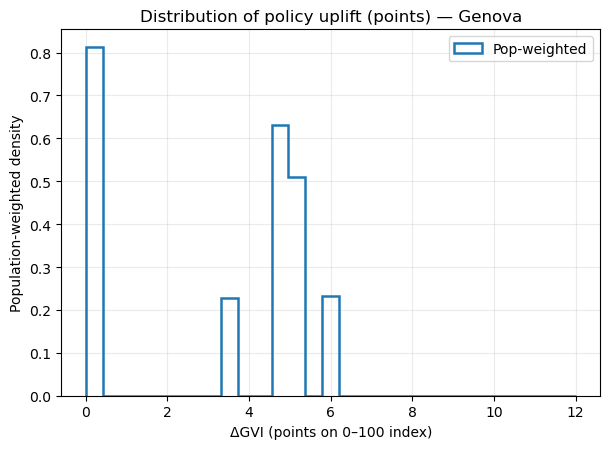

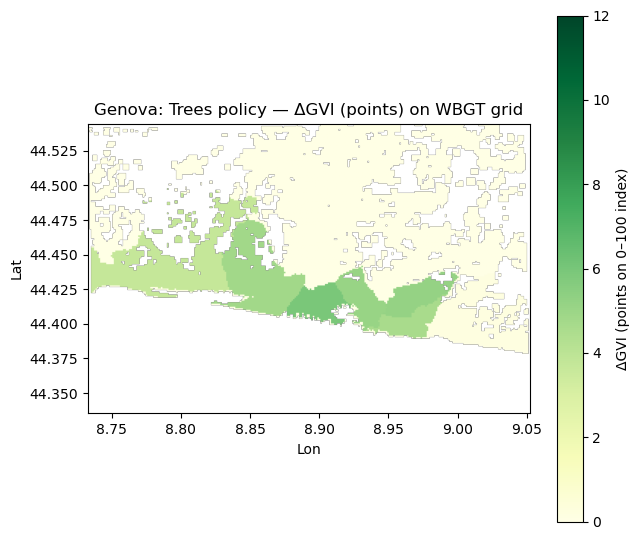

,muni_id,ΔGVI_points_popw,muni_name
0,3,5.940054,Centro Ovest
1,1,5.167485,Bassa Val Bisagno
2,2,5.073389,Centro Est
3,7,4.798199,Medio Ponente
4,6,4.608904,Medio Levante
5,8,3.679435,Ponente
6,4,0.187144,Levante
7,5,0.000000,Media Val Bisagno
8,9,0.000000,Val Polcevera


In [128]:
# change GVI in "points" (0–100 index points)
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from rasterio.transform import array_bounds

# Masks (only kept Municipi inside city)
POLICY  = (muni_on_ref > 0) & CITY_MASK
WEIGHTS = np.where(POLICY, pop_on_ref, 0.0)

# pop-weighted mean uplift (points)
den_w = np.nansum(WEIGHTS)
pw_mean_points = (np.nansum(dGVI_points * WEIGHTS) / den_w) if den_w > 0 else np.nan
print(f"Citywide ΔGVI (pop-weighted over Municipi) ≈ {pw_mean_points:.2f} points "
      f"(= {pw_mean_points/100:.4f} on 0–1 scale)")

# share of people with any uplift
share_people_uplift = float(np.nansum((dGVI_points > 0) * WEIGHTS) / den_w) if den_w>0 else np.nan
print(f"Share of population with ΔGVI>0: {share_people_uplift:.1%}")

# histogram (population-weighted)
m = POLICY & np.isfinite(dGVI_points) & (WEIGHTS > 0)
v = dGVI_points[m].ravel()
w = WEIGHTS[m].ravel()
cap_pts = int(round(CAP * 100))  # CAP from YAML, in points
vmax_bins = cap_pts if np.isfinite(cap_pts) and cap_pts > 0 else (np.nanmax(v) if v.size else 1)
bins = np.linspace(0, max(1, vmax_bins), 30)

plt.figure(figsize=(6.2,4.6))
plt.hist(v, bins=bins, weights=w, histtype="step", linewidth=1.8, density=True, label="Pop-weighted")
plt.xlabel("ΔGVI (points on 0–100 index)"); plt.ylabel("Population-weighted density")
plt.title(f"Distribution of policy uplift (points) — {CITY}")
plt.grid(alpha=0.25); plt.legend(); plt.tight_layout(); plt.show()

# map (points), fixed 0..CAP
left, bottom, right, top = array_bounds(HGT, WDT, ref_meta["transform"])
extent = (left, right, bottom, top)
plt.figure(figsize=(6.6,5.5))
im = plt.imshow(np.where(CITY_MASK, dGVI_points, np.nan), origin="upper",
                extent=extent, vmin=0, vmax=cap_pts, cmap="YlGn")
cb = plt.colorbar(im); cb.set_label("ΔGVI (points on 0–100 index)")
plt.title(f"{CITY}: Trees policy — ΔGVI (points) on WBGT grid")
plt.xlabel("Lon"); plt.ylabel("Lat"); plt.tight_layout(); plt.show()

# Municipio table in points
if 'muni_ok' in globals():
    ids = muni_on_ref[POLICY].astype(int)
    w   = WEIGHTS[POLICY]
    x   = dGVI_points[POLICY]
    size = int(np.nanmax(muni_on_ref)) + 1  
    den = np.bincount(ids, weights=w, minlength=size)
    num = np.bincount(ids, weights=w*x, minlength=size)
    by_muni = pd.DataFrame({
        "muni_id": np.arange(size, dtype=int),
        "ΔGVI_points_popw": np.divide(num, den, out=np.full_like(num, np.nan), where=den>0)
    })
    out = (by_muni.merge(muni_ok[["muni_id","muni_name"]], on="muni_id", how="inner")
                  .sort_values("ΔGVI_points_popw", ascending=False))
    display(out.reset_index(drop=True).head(10))

Coefficients say how many °C cooler per +1 GVI point for each month×LCZ. Multiplying by policy’s ΔGVI (in points) gives a monthly cooling map. Careful: we zero it outside built areas.

**Bridge to UrbClim daily grid and build the hazard multiplier f**

In [129]:
# bridge to UrbClim daily grid and build hazard multiplier f (cooling-only) 

p_UrbClim = P(paths.get("urbclim_daily_dir", "UrbClim/UrbClimWBGTmax"))
assert p_UrbClim.exists(), f"No UrbClim directory: {p_UrbClim}"

import xarray as xr, rasterio
from rasterio.warp import reproject
from rasterio.enums import Resampling
from affine import Affine
import numpy as np

# pulling parameters from YAML 
ucfg        = (cfg or {}).get("urbclim", {})
THRESH      = float(ucfg.get("thresh_wbgt", 28.0))
HOT_MONTHS  = list(map(int, ucfg.get("hot_months", [6,7,8,9])))
F_MIN, F_MAX = (lambda lo, hi: (float(lo), float(hi)))(*(ucfg.get("f_bounds", [0.4, 1.0])))

# loading daily WBGT files 
nc_files = sorted(p_UrbClim.glob("WBGT_year_daily_max_*.nc"))
assert nc_files, f"No UrbClim daily files at {p_UrbClim}"

ds = xr.open_mfdataset(nc_files, combine="by_coords", decode_times=True, chunks={"time": 90})

# picking the right variable
candidates = [c for c in ucfg.get("variable_candidates", []) if isinstance(c, str)]
if not candidates:
    candidates = ["wbgt_max","WBGT_max","wbgt","WBGT"]
vname = next((v for v in candidates if v in ds.data_vars), None)
assert vname, f"No WBGT-like variable found. Available: {list(ds.data_vars)}"
da = ds[vname]

# building Affine for UrbClim x/y (projected, typically EPSG:3035)
x_uc = ds["x"].values; y_uc = ds["y"].values
dx_uc = float(np.diff(x_uc).mean()); dy_uc = float(np.diff(y_uc).mean())
transform_uc = (Affine.translation(float(x_uc.min()) - dx_uc/2,
                                   float(y_uc.min()) - dy_uc/2)
                * Affine.scale(dx_uc, dy_uc))

# reprojecting masks from WBGT ref grid yo UrbClim grid
Hh, Ww = ref_data.shape
built_mask_ref  = ((lcz_on_ref >= 1) & (lcz_on_ref <= 10) & np.isfinite(ref_data)).astype("uint8")
policy_mask_ref = np.isfinite(dGVI_map_model).astype("uint8")

built_uc  = np.zeros((len(y_uc), len(x_uc)), dtype="uint8")
policy_uc = np.zeros_like(built_uc, dtype="uint8")

reproject(
    source=built_mask_ref, destination=built_uc,
    src_transform=ref_meta["transform"], src_crs=ref_meta["crs"],
    dst_transform=transform_uc,          dst_crs=rasterio.crs.CRS.from_epsg(3035),
    resampling=Resampling.nearest, src_nodata=0, dst_nodata=0
)
reproject(
    source=policy_mask_ref, destination=policy_uc,
    src_transform=ref_meta["transform"], src_crs=ref_meta["crs"],
    dst_transform=transform_uc,          dst_crs=rasterio.crs.CRS.from_epsg(3035),
    resampling=Resampling.nearest, src_nodata=0, dst_nodata=0
)

# Helper: reproject a ref-grid 2D layer to UrbClim grid
def _to_uc(layer_2d: np.ndarray) -> np.ndarray:
    dst = np.full((len(y_uc), len(x_uc)), np.nan, dtype="float32")
    reproject(
        source=layer_2d.astype("float32"), destination=dst,
        src_transform=ref_meta["transform"], src_crs=ref_meta["crs"],
        dst_transform=transform_uc,          dst_crs=rasterio.crs.CRS.from_epsg(3035),
        resampling=Resampling.bilinear, src_nodata=np.nan, dst_nodata=np.nan
    )
    return dst

# reprojecting monthly ΔWBGT (ref grid -> UrbClim), mask to built and pixels we kept
months = np.arange(1, 13, dtype=int)
dWBGT_uc = np.stack([_to_uc(dWBGT_stack[m-1]) for m in months], axis=0).astype("float32")
dWBGT_uc = np.where((built_uc[None,:,:] == 1) & (policy_uc[None,:,:] == 1), dWBGT_uc, 0.0).astype("float32")

# COOLING-ONLY: forbid warming 
# (here the problem was that conversely to rome where the ΔWBGT (°C) across months was of max 0, here it's 1.3185
# some pixels were warming before fixing the code 
dWBGT_uc = np.minimum(dWBGT_uc, 0.0).astype("float32")

# Expected hot-days baseline vs after (per year), then f = E1 / E0
E0 = np.zeros((len(y_uc), len(x_uc)), dtype="float32")
E1 = np.zeros_like(E0)

for m in HOT_MONTHS:
    da_m = da.sel(time=(ds["time"].dt.month == m))
    prob0_m = (da_m > THRESH).groupby("time.day").mean("time", skipna=True)  # P(hot) per day
    e0_m = prob0_m.sum("day")                                               # days per month

    delta_m = xr.DataArray(dWBGT_uc[m-1], coords={"y": ds["y"], "x": ds["x"]}, dims=("y","x"))
    prob1_m = (da_m > (THRESH - delta_m)).groupby("time.day").mean("time", skipna=True)
    e1_m = prob1_m.sum("day")

    E0 += np.nan_to_num(e0_m.values, nan=0.0).astype("float32")
    E1 += np.nan_to_num(e1_m.values, nan=0.0).astype("float32")

print("E0 min/med/max:",
      float(np.nanmin(E0)), float(np.nanmedian(E0)), float(np.nanmax(E0)))
print("E1 min/med/max:",
      float(np.nanmin(E1)), float(np.nanmedian(E1)), float(np.nanmax(E1)))

with np.errstate(divide="ignore", invalid="ignore"):
    f_uc = E1 / E0
    no_base = (E0 <= 0)
    f_uc = np.where(no_base & (E1 <= 0), 1.0, f_uc)                 # 0/0 → no change
    f_uc = np.where(no_base & (E1 > 0),  (E1 + 1.0) / (E0 + 1.0), f_uc)

# clipping to [F_MIN, F_MAX] from YAML
f_uc = np.clip(f_uc.astype("float32"), F_MIN, F_MAX)

# back to WBGT ref grid (keep 1.0 outside hazard)
f_ref = np.full((Hh, Ww), np.nan, dtype="float32")
reproject(
    source=f_uc.astype("float32"), destination=f_ref,
    src_transform=transform_uc,          src_crs=rasterio.crs.CRS.from_epsg(3035),
    dst_transform=ref_meta["transform"], dst_crs=ref_meta["crs"],
    resampling=Resampling.bilinear, src_nodata=np.nan, dst_nodata=np.nan
)
f_ref = np.where(np.isfinite(ref_data), np.nan_to_num(f_ref, nan=1.0), 1.0).astype("float32")

print(f"{CITY} — UrbClim f min/med/max:",
      float(np.nanmin(f_uc)), float(np.nanmedian(f_uc[np.isfinite(f_uc)])), float(np.nanmax(f_uc)))
print("Ref-grid f min/med/max:",
      float(np.nanmin(f_ref)), float(np.nanmedian(f_ref[np.isfinite(ref_data)])), float(np.nanmax(f_ref)))

E0 min/med/max: 0.0 5.300000190734863 25.900001525878906
E1 min/med/max: 0.0 5.199999809265137 25.900001525878906
Genova — UrbClim f min/med/max: 0.4000000059604645 1.0 1.0
Ref-grid f min/med/max: 0.4000000059604645 1.0 1.0


> **Interpretation:**
> - Reduction seems low because most pixels have no ΔGVI (by design) or are not built.
> - I did this choice of built because the cooling coefficients are estimated for built classes.
> - In those pixels E1=E0, so f=1
> - A smaller subset where the policy acts shows f<1, and some pixels hit 0.4 (60% reduction).

For each calendar day we average the number of days with WBGT > 28°C across years, shift by the cooling, and compare expected hot-days E1 vs E0. The ratio f_ref scales annual hazard for each event.

**Apply to hazard and compute impacts**

**Rebuilding functions**

In [130]:
# From f_ref to impacts (baseline vs trees) 
from copy import deepcopy
import numpy as np, pandas as pd
from scipy.sparse import diags

# CLIMADA imports 
try:
    from climada.hazard import Hazard
except Exception:
    from climada.hazard.base import Hazard
try:
    from climada.entity import Exposures
except Exception:
    from climada.entity.exposures.base import Exposures
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet
from climada.engine import ImpactCalc

haz_path = INT / f"hazard_HEAT_{SLUG}.h5"
exp_path = INT / f"exposure_people_{SLUG}.h5"

assert haz_path.exists(), f"Missing: {haz_path}"
assert exp_path.exists(), f"Missing: {exp_path}"

H   = Hazard.from_hdf5(haz_path)
exp = Exposures.from_hdf5(exp_path)

# repairing H metadata so ImpactCalc can build an Impact 
n_ev = len(H.event_id)
import numpy as _np
if not getattr(H, "haz_type", None): H.haz_type = "HEAT"
if not hasattr(H, "event_name") or len(getattr(H, "event_name", [])) != n_ev:
    H.event_name = _np.array([f"HEAT_{int(y)}" for y in H.event_id], dtype=object)
if not hasattr(H, "date") or len(getattr(H, "date", [])) != n_ev:
    H.date = _np.array([_np.datetime64(f"{int(y)}-07-01") for y in H.event_id])
if not hasattr(H, "frequency") or len(getattr(H, "frequency", [])) != n_ev:
    H.frequency = _np.ones(n_ev, dtype=float)
if not getattr(H, "frequency_unit", None): H.frequency_unit = "1/year"

# rebuilding age impact functions from saved parameters 
# loading the IF curves from notebook 4
import json, numpy as np
from pathlib import Path
from climada.entity.impact_funcs import ImpactFunc, ImpactFuncSet

freeze_path = Path(INT) / f"if_curves_frozen_{SLUG}.json"
if not freeze_path.exists():
    freeze_path = Path(INT) / "if_curves_frozen.json"  # fallback if you saved without suffix
assert freeze_path.exists(), f"Missing {freeze_path}"

with open(freeze_path, "r") as fh:
    IF_FREEZE = json.load(fh)

def _mk_if(v):
    f = ImpactFunc(
        haz_type="HEAT",
        id=int(v["id"]),
        intensity=np.asarray(v["intensity"], float),
        mdd=np.asarray(v["mdd"], float),
        paa=np.ones(len(v["intensity"]), float),
        name=v.get("name", "IF"),
    )
    f.check()
    return f

# Dict used in your per-pixel loop (keys like "<15","15-64","65+")
age_ifs = {k: _mk_if(v) for k, v in IF_FREEZE.items()}

# Set used by ImpactCalc
impf_set_age = ImpactFuncSet(list(age_ifs.values()))
impf_set_age.check()

print(f" Loaded {freeze_path.name} with {len(age_ifs)} age-specific IFs.")

# applying the attenuation to the hazard and run impacts 
# S scales each pixel’s intensity by f_ref 
S = diags(f_ref.ravel().astype(float))
H_trees_dd = deepcopy(H)
H_trees_dd.intensity = H.intensity @ S

# City totals per 100k for each event
city_pop = float(exp.gdf["value"].sum())
impact_base  = ImpactCalc(exp, impf_set_age, H).impact()
impact_trees = ImpactCalc(exp, impf_set_age, H_trees_dd).impact()
base_per100k  = np.ravel(impact_base.at_event)  / city_pop * 1e5
trees_per100k = np.ravel(impact_trees.at_event) / city_pop * 1e5

for name, b, t in zip(H.event_name, base_per100k, trees_per100k):
    print(f"{CITY} {name}: baseline={b:5.1f} → {t:5.1f} (Δ {t-b:+.1f} per 100k)")

# Municipio table for 2050 (per-100k and totals) 
def _row_to_grid(mat, irow, shape):
    row = mat[irow, :]
    if hasattr(row, "toarray"): row = row.toarray()
    return np.asarray(row).ravel().reshape(shape)

year_focus = int(((cfg or {}).get("trees", {}) or {}).get("focus_year", 2050))
years = [int(y) for y in H.event_id.tolist()]
assert year_focus in years, f"Year {year_focus} not found in hazard events: {years}"
i_ev = years.index(year_focus)

I_base = _row_to_grid(H.intensity,         i_ev, ref_data.shape)
I_tree = _row_to_grid(H_trees_dd.intensity, i_ev, ref_data.shape)
mask_city = np.isfinite(ref_data)

# deaths per pixel = sum_age(pop_age * mdd_age(I))
deaths_base = np.zeros_like(I_base, dtype=float)
deaths_tree = np.zeros_like(I_base, dtype=float)
for age_lbl, f in age_ifs.items():
    mdd_b = np.interp(I_base, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
    mdd_t = np.interp(I_tree, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
    pop_age = np.nan_to_num(age_on_ref[age_lbl], nan=0.0)
    deaths_base += np.where(mask_city, pop_age * mdd_b, 0.0)
    deaths_tree += np.where(mask_city, pop_age * mdd_t, 0.0)

deaths_avo = deaths_base - deaths_tree

rows = []
for mid, name in zip(muni_ok["muni_id"], muni_ok["muni_name"]):
    m = (muni_on_ref == int(mid)) & mask_city
    if not m.any(): continue
    pop_m = sum(float(np.nansum(age_on_ref[a][m])) for a in age_ifs)
    d_b, d_t = float(np.nansum(deaths_base[m])), float(np.nansum(deaths_tree[m]))
    d_avo = d_b - d_t
    rows.append({
        "muni_id": int(mid), "muni_name": name,
        "deaths_base": d_b, "deaths_trees": d_t, "deaths_avo": d_avo,
        "Δ per 100k": (d_t - d_b)/pop_m*1e5 if pop_m>0 else 0.0,
        "avo_per_100k": d_avo/pop_m*1e5 if pop_m>0 else 0.0
    })

tbl_muni = pd.DataFrame(rows).sort_values("muni_id").reset_index(drop=True)
display(tbl_muni.head(10))

# Mass-balance check (restricted to kept municipi)
mask_kept = np.isin(muni_on_ref, muni_ok["muni_id"].values) & mask_city
print(f"{CITY} {year_focus} — City avoided (kept only):", float(np.nansum(deaths_avo[mask_kept])))
print(f"{CITY} {year_focus} — Sum of kept rows:        ", float(tbl_muni["deaths_avo"].sum()))

 Loaded if_curves_frozen_genova.json with 3 age-specific IFs.
Genova HEAT_2030: baseline=  0.0 →   0.0 (Δ +0.0 per 100k)
Genova HEAT_2050: baseline= 91.0 →  84.3 (Δ -6.7 per 100k)
Genova HEAT_2070: baseline=6958.4 → 6606.7 (Δ -351.7 per 100k)
Genova HEAT_2090: baseline=42507.0 → 40617.5 (Δ -1889.4 per 100k)
Genova HEAT_2100: baseline=70155.0 → 67068.6 (Δ -3086.4 per 100k)


,muni_id,muni_name,deaths_base,deaths_trees,deaths_avo,Δ per 100k,avo_per_100k
0,1,Bassa Val Bisagno,30.102026,28.727102,1.374924,-2.945318,2.945318
1,2,Centro Est,57.139338,52.430749,4.708589,-7.028419,7.028419
2,3,Centro Ovest,79.187572,77.974678,1.212894,-2.333614,2.333614
3,4,Levante,33.191846,32.600602,0.591243,-0.884249,0.884249
4,5,Media Val Bisagno,18.940068,18.918179,0.021889,-0.040224,0.040224
5,6,Medio Levante,66.327380,50.680993,15.646386,-22.385282,22.385282
6,7,Medio Ponente,94.157557,86.383575,7.773982,-11.035794,11.035794
7,8,Ponente,40.978789,34.108414,6.870374,-13.525453,13.525453
8,9,Val Polcevera,82.905987,82.828980,0.077007,-0.128897,0.128897


Genova 2050 — City avoided (kept only): 38.277289563938446
Genova 2050 — Sum of kept rows:         38.27728956393845


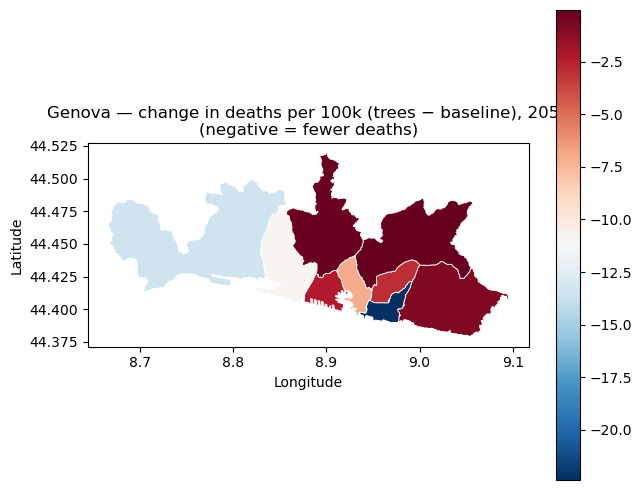

In [131]:
# map
muni_map = muni_ok.merge(tbl_muni[["muni_id","Δ per 100k"]], on="muni_id", how="left")
ax = muni_map.plot(column="Δ per 100k", cmap="RdBu_r", legend=True,
                   edgecolor="white", linewidth=0.6, figsize=(6.5,5))
ax.set_title(f"{CITY} — change in deaths per 100k (trees − baseline), {year_focus}\n(negative = fewer deaths)")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout(); plt.show()

In [132]:
years = [int(y) for y in H.event_id.tolist()]
i_ev = years.index(year_focus)

I_base = _row_to_grid(H.intensity,         i_ev, ref_data.shape)
I_tree = _row_to_grid(H_trees_dd.intensity, i_ev, ref_data.shape)

avo_city_age = {}
per100k_age  = {}
for age_lbl, f in age_ifs.items():
    mdd_b = np.interp(I_base, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
    mdd_t = np.interp(I_tree, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])
    pop = np.nan_to_num(age_on_ref[age_lbl], 0.0)
    d_b, d_t = float(np.nansum(pop * mdd_b)), float(np.nansum(pop * mdd_t))
    avo_city_age[age_lbl] = d_b - d_t
    per100k_age[age_lbl]  = (d_b - d_t) / float(pop.sum()) * 1e5

print(f"City avoided deaths in {year_focus} by age:", avo_city_age)
print(f"Avoided per 100k in {year_focus} by age:",   per100k_age)
print("Sum over ages:", sum(avo_city_age.values()))

City avoided deaths in 2050 by age: {'<15': 0.0, '15-64': 0.0, '65+': 38.32606955632241}
Avoided per 100k in 2050 by age: {'<15': 0.0, '15-64': 0.0, '65+': 20.397984537819784}
Sum over ages: 38.32606955632241


**2 Maps: Original hazard vs hazard after policy**

In [133]:
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import matplotlib.pyplot as plt

# event index from year_focus
years = [int(y) for y in H.event_id.tolist()]
i_ev = years.index(year_focus)

I_base = _row_to_grid(H.intensity,         i_ev, ref_data.shape).astype(float)
I_tree = _row_to_grid(H_trees_dd.intensity, i_ev, ref_data.shape).astype(float)

# extent from ref_meta (ref CRS)
T = ref_meta["transform"]; h, w = ref_meta["height"], ref_meta["width"]
xmin, ymax = T.c, T.f
xmax = xmin + T.a * w
ymin = ymax + T.e * h
extent = (xmin, xmax, ymin, ymax)

fua_ref = fua.to_crs(ref_meta["crs"])

# mask outside city
I_base_m = np.where(CITY_MASK, I_base, np.nan)
I_tree_m = np.where(CITY_MASK, I_tree, np.nan)

# common scale on valid pixels
mask = CITY_MASK & np.isfinite(I_base) & np.isfinite(I_tree)
if np.any(mask):
    vals = np.concatenate([I_base[mask].ravel(), I_tree[mask].ravel()])
    vmin = float(np.nanpercentile(vals, 1))
    vmax = float(np.nanpercentile(vals, 99))
else:
    vmin, vmax = np.nanmin(I_base_m), np.nanmax(I_base_m)

# change map (Trees − Baseline), zero-centered norm
D = (I_tree - I_base).astype(float)
D_m = np.where(CITY_MASK, D, np.nan)
dabs = np.abs(D_m[np.isfinite(D_m)])
dlim = float(np.nanpercentile(dabs, 99)) if dabs.size else 1.0
norm0 = TwoSlopeNorm(vmin=-dlim, vcenter=0.0, vmax=dlim)

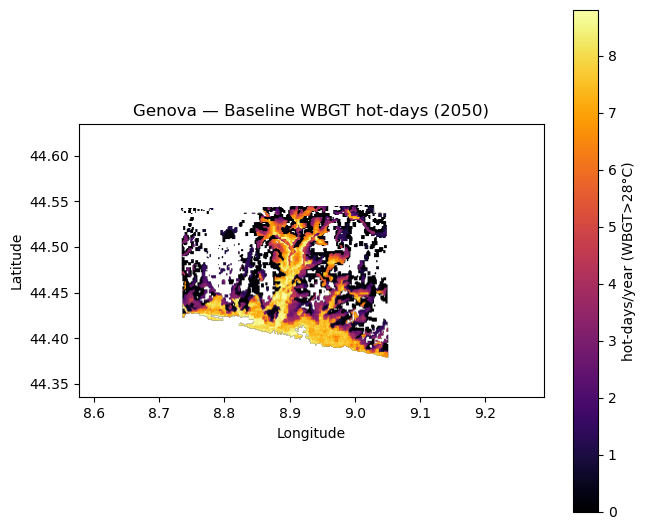

In [134]:
plt.figure(figsize=(6.8, 5.4))
im = plt.imshow(I_base_m, origin="upper", extent=extent, vmin=vmin, vmax=vmax, cmap="inferno")
fua_ref.boundary.plot(ax=plt.gca(), color="white", linewidth=0.8, alpha=0.8)
plt.title(f"{CITY} — Baseline WBGT hot-days ({year_focus})")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
cb = plt.colorbar(im); cb.set_label(getattr(H, "units", "hot-days / year"))
plt.tight_layout(); plt.show()

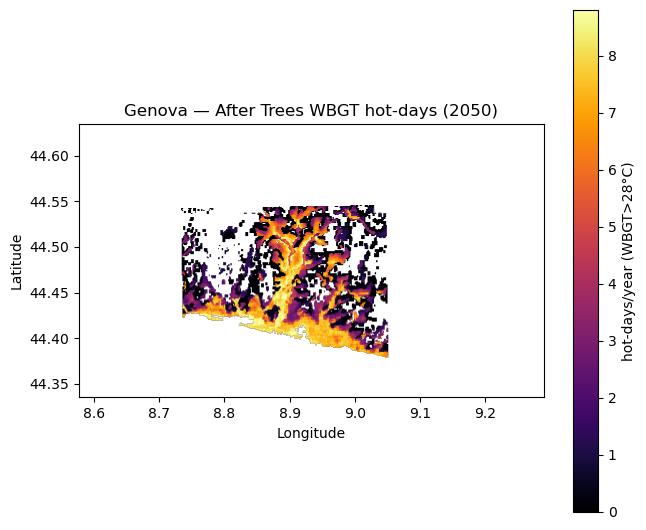

In [135]:
plt.figure(figsize=(6.8, 5.4))
im = plt.imshow(I_tree_m, origin="upper", extent=extent, vmin=vmin, vmax=vmax, cmap="inferno")
fua_ref.boundary.plot(ax=plt.gca(), color="white", linewidth=0.8, alpha=0.8)
plt.title(f"{CITY} — After Trees WBGT hot-days ({year_focus})")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
cb = plt.colorbar(im); cb.set_label(getattr(H, "units", "hot-days / year"))
plt.tight_layout(); plt.show()

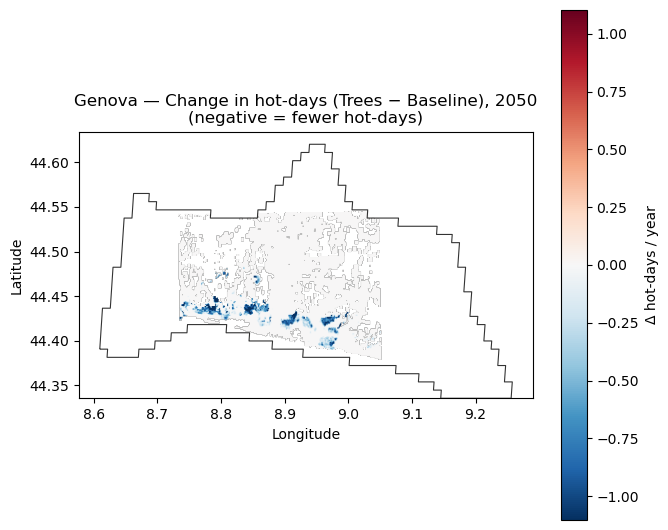

In [136]:
plt.figure(figsize=(6.8, 5.4))
im = plt.imshow(D_m, origin="upper", extent=extent, cmap="RdBu_r", norm=norm0)
fua_ref.boundary.plot(ax=plt.gca(), color="k", linewidth=0.8, alpha=0.8)
plt.title(f"{CITY} — Change in hot-days (Trees − Baseline), {year_focus}\n(negative = fewer hot-days)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
cb = plt.colorbar(im); cb.set_label("Δ hot-days / year")
plt.tight_layout(); plt.show()

In [137]:
# Validation (focus year=2050): pixel sums vs ImpactCalc; Municipio breakdown (incl. ID 0 if present)

import numpy as np
import pandas as pd
from climada.entity.impact_funcs import ImpactFuncSet
from climada.engine import ImpactCalc

# helpers 
def _row_to_grid(mat, irow, shape):
    row = mat[irow, :]
    if hasattr(row, "toarray"):
        row = row.toarray()
    return np.asarray(row).ravel().reshape(shape)

def mdd_lookup(I, f):
    return np.interp(I, f.intensity, f.mdd, left=f.mdd[0], right=f.mdd[-1])

def _pop_sum_over_ages(mask):
    return sum(float(np.nansum(np.nan_to_num(age_on_ref[a], 0.0)[mask])) for a in age_ifs)

# focus year from YAML (default 2050) 
year_focus = int(((cfg or {}).get("trees", {}) or {}).get("focus_year", 2050))
years = [int(y) for y in H.event_id.tolist()]
assert year_focus in years, f"Year {year_focus} not in hazard events: {years}"
i_ev = years.index(year_focus)

# intensities on ref grid
I_base = _row_to_grid(H.intensity,         i_ev, ref_data.shape)
I_tree = _row_to_grid(H_trees_dd.intensity, i_ev, ref_data.shape)

# masks
CITY_PIX = CITY_MASK & (muni_on_ref >= 0)
OUT_PIX  = CITY_MASK & (muni_on_ref == 0)

# deaths per pixel = sum_age(pop_age * mdd_age(I)) 
deaths_base = np.zeros_like(I_base, dtype=float)
deaths_tree = np.zeros_like(I_base, dtype=float)

for age_lbl in sorted(age_ifs.keys()):
    f = age_ifs[age_lbl]
    pop_age = np.nan_to_num(age_on_ref[age_lbl], nan=0.0)
    mdd_b = mdd_lookup(I_base, f)
    mdd_t = mdd_lookup(I_tree, f)
    deaths_base += np.where(CITY_PIX, pop_age * mdd_b, 0.0)
    deaths_tree += np.where(CITY_PIX, pop_age * mdd_t, 0.0)

deaths_avo = deaths_base - deaths_tree

# ImpactCalc totals using the same IF set 
impf_set_age = ImpactFuncSet(list(age_ifs.values())); impf_set_age.check()
impact_base  = ImpactCalc(exp, impf_set_age, H).impact()
impact_trees = ImpactCalc(exp, impf_set_age, H_trees_dd).impact()

tot_base_pix = float(np.nansum(deaths_base))
tot_tree_pix = float(np.nansum(deaths_tree))
tot_base_IC  = float(np.ravel(impact_base.at_event)[i_ev])
tot_tree_IC  = float(np.ravel(impact_trees.at_event)[i_ev])

# consistent per-100k denominator (using exposure sum to align with ImpactCalc) 
den_exposure = float(exp.gdf["value"].sum())
print(f"{CITY} {year_focus} — population denominator (Exposure sum): {den_exposure:,.0f}")

print(f"[{year_focus}] pixel-sum vs ImpactCalc — base: {tot_base_pix:.2f} vs {tot_base_IC:.2f} "
      f"({tot_base_pix/den_exposure*1e5:.1f} vs {tot_base_IC/den_exposure*1e5:.1f} per 100k)")
print(f"[{year_focus}] pixel-sum vs ImpactCalc — tree: {tot_tree_pix:.2f} vs {tot_tree_IC:.2f} "
      f"({tot_tree_pix/den_exposure*1e5:.1f} vs {tot_tree_IC/den_exposure*1e5:.1f} per 100k)")

# checks 
assert np.isclose(tot_base_pix, tot_base_IC,  rtol=1e-6, atol=1e-3),  "Base totals mismatch"
assert np.isclose(tot_tree_pix, tot_tree_IC,  rtol=1e-6, atol=1e-3),  "Trees totals mismatch"

# Municipio breakdown (kept regions only if available) 
M = muni_ok if 'muni_ok' in globals() else muni

rows = []
for mid, name in zip(M["muni_id"], M["muni_name"]):
    m = CITY_MASK & (muni_on_ref == int(mid))
    if not np.any(m):
        continue

    # denominator from grid-aligned population
    pop_m = float(np.nansum(pop_on_ref[m]))

    d_b   = float(np.nansum(deaths_base[m]))
    d_t   = float(np.nansum(deaths_tree[m]))
    d_avo = d_b - d_t
    rows.append({
        "muni_id": int(mid), "muni_name": name,
        "deaths_base": d_b, "deaths_tree": d_t, "deaths_avo": d_avo,
        "pop_m": pop_m,
        "avo_per_100k": (d_avo / pop_m * 1e5) if pop_m > 0 else np.nan,
        "Δ per 100k":   ((d_t - d_b) / pop_m * 1e5) if pop_m > 0 else np.nan,
    })

# outside-bucket row (ID 0)
if OUT_PIX.any():
    pop_0 = float(np.nansum(pop_on_ref[OUT_PIX]))   
    d_b0  = float(np.nansum(deaths_base[OUT_PIX]))
    d_t0  = float(np.nansum(deaths_tree[OUT_PIX]))
    d_a0  = d_b0 - d_t0
    rows.append({
        "muni_id": 0, "muni_name": "Fuori Municipi (FUA)",
        "deaths_base": d_b0, "deaths_tree": d_t0, "deaths_avo": d_a0,
        "pop_m": pop_0,
        "avo_per_100k": (d_a0 / pop_0 * 1e5) if pop_0 > 0 else np.nan,
        "Δ per 100k":   ((d_t0 - d_b0) / pop_0 * 1e5) if pop_0 > 0 else np.nan,
    })
    
benef_focus = (pd.DataFrame(rows)
               .sort_values("deaths_avo", ascending=False)
               .reset_index(drop=True))

# Totals row (scope = all CITY pixels covered by raster labels >=0)
tot_row = pd.DataFrame([{
    "muni_id": 999,
    "muni_name": f"{CITY} — Totale (scope)",
    "deaths_base": float(np.nansum(deaths_base[CITY_PIX])),
    "deaths_tree": float(np.nansum(deaths_tree[CITY_PIX])),
    "deaths_avo":  float(np.nansum(deaths_avo[CITY_PIX])),
    "pop_m": den_exposure,
    "avo_per_100k": (float(np.nansum(deaths_avo[CITY_PIX])) / den_exposure * 1e5) if den_exposure>0 else np.nan,
    "Δ_per_100k_(trees−base)": (float(np.nansum((deaths_tree - deaths_base)[CITY_PIX])) / den_exposure * 1e5
                                 if den_exposure>0 else np.nan),
}])
benef_focus = pd.concat([benef_focus, tot_row], ignore_index=True)

display(benef_focus.head(10))

# cross-check raster vs table (exclude totals row in the sum) 
city_all = float(np.nansum(deaths_avo[CITY_PIX]))
sum_rows = float(benef_focus.loc[benef_focus["muni_id"] != 999, "deaths_avo"].sum())
print(f"{CITY} {year_focus} — avoided deaths (raster sum): {city_all:.3f}")
print(f"{CITY} {year_focus} — avoided deaths (sum of rows): {sum_rows:.3f}")
assert np.isclose(city_all, sum_rows, rtol=1e-6, atol=1e-3), "Municipio sum ≠ raster sum"

Genova 2050 — population denominator (Exposure sum): 573,935
[2050] pixel-sum vs ImpactCalc — base: 522.28 vs 522.28 (91.0 vs 91.0 per 100k)
[2050] pixel-sum vs ImpactCalc — tree: 483.95 vs 483.95 (84.3 vs 84.3 per 100k)


,muni_id,muni_name,deaths_base,deaths_tree,deaths_avo,pop_m,avo_per_100k,Δ per 100k,Δ_per_100k_(trees−base)
0,6,Medio Levante,66.327380,50.680993,15.646386,69895.867188,22.385281,-22.385281,NaN
1,7,Medio Ponente,94.157557,86.383575,7.773982,70443.343750,11.035794,-11.035794,NaN
2,8,Ponente,40.978789,34.108414,6.870374,50795.890625,13.525453,-13.525453,NaN
3,2,Centro Est,57.139338,52.430749,4.708589,66993.570312,7.028419,-7.028419,NaN
4,1,Bassa Val Bisagno,30.102026,28.727102,1.374924,46681.695312,2.945318,-2.945318,NaN
5,3,Centro Ovest,79.187572,77.974678,1.212894,51974.925781,2.333614,-2.333614,NaN
6,4,Levante,33.191846,32.600602,0.591243,66863.921875,0.884249,-0.884249,NaN
7,9,Val Polcevera,82.905987,82.828980,0.077007,59742.617188,0.128897,-0.128897,NaN
8,0,Fuori Municipi (FUA),19.350234,19.301454,0.048780,36124.562500,0.135033,-0.135033,NaN
9,5,Media Val Bisagno,18.940068,18.918179,0.021889,54418.554688,0.040224,-0.040224,NaN


Genova 2050 — avoided deaths (raster sum): 38.326
Genova 2050 — avoided deaths (sum of rows): 38.326


In [138]:
# Municipio population-weighted ΔWBGT summaries (July and Jun–Sep): ITT and ETT 
# ITT: Pop average effect, average cooling for residents 
# ETT: exclude 0: how much cooling where policy acted/on who policy acted
# Municipio population-weighted ΔWBGT summaries (July and Jun–Sep): ITT and ETT
import numpy as np
import pandas as pd

def weighted_mean(values, weights):
    v = np.asarray(values, float).ravel()
    w = np.asarray(weights, float).ravel()
    m = np.isfinite(v) & np.isfinite(w) & (w > 0)
    return float(np.sum(v[m] * w[m]) / np.sum(w[m])) if m.any() else np.nan

# mass
built_mask = (lcz_on_ref >= 1) & (lcz_on_ref <= 10) & HAZ_MASK
scope_mask = np.isfinite(dGVI_map_model) & CITY_MASK  # policy scope inside city
M = muni_ok if 'muni_ok' in globals() else muni

def muni_popw_table(field_2d, title_col, muni_frame, include_zeros: bool):
    finite = np.isfinite(field_2d)
    if include_zeros:
        base_mask = built_mask & scope_mask & finite           # ITT: keep zeros
        tag = "ITT"
    else:
        base_mask = built_mask & scope_mask & finite & (field_2d != 0)  # ETT: exclude zeros
        tag = "ETT"

    rows = []
    mids = muni_frame["muni_id"].astype(int).values
    names = muni_frame["muni_name"].values

    for mid, name in zip(mids, names):
        m = (muni_on_ref.astype(int) == int(mid)) & base_mask
        if not np.any(m):
            continue
        vals = field_2d[m].astype(float)
        w    = pop_on_ref[m].astype(float)
        rows.append({
            "muni_id": int(mid),
            "muni_name": name,
            f"{title_col}_{tag}_popw_mean": weighted_mean(vals, w),
            f"{title_col}_{tag}_area_mean": float(np.nanmean(vals)),
            "pix": int(m.sum()),
            "pop_sum": float(np.nansum(w)),
            f"share_cooling_{tag}_popw": weighted_mean((vals < 0).astype(float), w),
        })

    out = pd.DataFrame(rows).sort_values(f"{title_col}_{tag}_popw_mean").reset_index(drop=True)

    # City line: same scope + same kept Municipi set
    city_mask = np.isin(muni_on_ref.astype(int), mids) & base_mask
    if np.any(city_mask):
        vals_c = field_2d[city_mask].astype(float)
        w_c    = pop_on_ref[city_mask].astype(float)
        out = pd.concat([out, pd.DataFrame([{
            "muni_id": 999,
            "muni_name": f"{CITY} (built+policy, {tag})",
            f"{title_col}_{tag}_popw_mean": weighted_mean(vals_c, w_c),
            f"{title_col}_{tag}_area_mean": float(np.nanmean(vals_c)),
            "pix": int(city_mask.sum()),
            "pop_sum": float(np.nansum(w_c)),
            f"share_cooling_{tag}_popw": weighted_mean((vals_c < 0).astype(float), w_c),
        }])], ignore_index=True)

    return out

# July
m = 7
dWBGT_July = dWBGT_stack[m-1]
df_jul_ITT = muni_popw_table(dWBGT_July, "ΔWBGT_Jul", M, include_zeros=True)
df_jul_ETT = muni_popw_table(dWBGT_July, "ΔWBGT_Jul", M, include_zeros=False)
display(df_jul_ITT); display(df_jul_ETT)

# Jun–Sep seasonal mean
hot_months = [6, 7, 8, 9]
idx = [mm - 1 for mm in hot_months]
arr   = dWBGT_stack[idx, :, :].astype(float)
count = np.sum(np.isfinite(arr), axis=0)
sum_  = np.nansum(arr, axis=0)
seasonal_mean = np.full_like(sum_, np.nan, dtype=float)
np.divide(sum_, count, out=seasonal_mean, where=(count > 0))

df_season_ITT = muni_popw_table(seasonal_mean, "ΔWBGT_Season", M, include_zeros=True)
df_season_ETT = muni_popw_table(seasonal_mean, "ΔWBGT_Season", M, include_zeros=False)
display(df_season_ITT); display(df_season_ETT)

,muni_id,muni_name,ΔWBGT_Jul_ITT_popw_mean,ΔWBGT_Jul_ITT_area_mean,pix,pop_sum,share_cooling_ITT_popw
0,4,Levante,-0.004622,-0.010914,1086,63073.376466,0.922038
1,5,Media Val Bisagno,0.000000,0.000000,991,46842.530353,0.000000
2,9,Val Polcevera,0.000000,0.000000,1194,50186.785073,0.000000
3,8,Ponente,0.046626,-0.091024,1100,45678.280649,0.554551
4,6,Medio Levante,0.055183,0.031561,543,69695.475903,0.624437
5,7,Medio Ponente,0.060063,0.003521,1086,65656.074087,0.380719
6,3,Centro Ovest,0.072988,0.040521,614,50661.166381,0.329375
7,1,Bassa Val Bisagno,0.097180,-0.066108,471,44643.564096,0.379451
8,2,Centro Est,0.099355,0.054119,559,66236.555574,0.437068
9,999,"Genova (built+policy, ITT)",0.048232,-0.008768,7644,502673.808583,0.426878


,muni_id,muni_name,ΔWBGT_Jul_ETT_popw_mean,ΔWBGT_Jul_ETT_area_mean,pix,pop_sum,share_cooling_ETT_popw
0,4,Levante,-0.004622,-0.010914,1086,63073.376466,0.922038
1,8,Ponente,0.049186,-0.095998,1043,43301.252113,0.584993
2,6,Medio Levante,0.055183,0.031561,543,69695.475903,0.624437
3,7,Medio Ponente,0.080264,0.004405,868,49131.785832,0.508764
4,1,Bassa Val Bisagno,0.097180,-0.066108,471,44643.564096,0.379451
5,2,Centro Est,0.102769,0.059202,511,64035.812465,0.452089
6,3,Centro Ovest,0.104716,0.069692,357,35311.094809,0.472558
7,999,"Genova (built+policy, ETT)",0.065670,-0.013737,4879,369192.361683,0.581216


,muni_id,muni_name,ΔWBGT_Season_ITT_popw_mean,ΔWBGT_Season_ITT_area_mean,pix,pop_sum,share_cooling_ITT_popw
0,4,Levante,-0.004914,-0.011631,1086,63073.376466,0.922038
1,5,Media Val Bisagno,0.000000,0.000000,991,46842.530353,0.000000
2,9,Val Polcevera,0.000000,0.000000,1194,50186.785073,0.000000
3,8,Ponente,0.049386,-0.097260,1100,45678.280649,0.554551
4,6,Medio Levante,0.058603,0.033343,543,69695.475903,0.624437
5,7,Medio Ponente,0.063760,0.003576,1086,65656.074087,0.380719
6,3,Centro Ovest,0.077517,0.043012,614,50661.166381,0.329375
7,1,Bassa Val Bisagno,0.103208,-0.070589,471,44643.564096,0.379451
8,2,Centro Est,0.105553,0.057401,559,66236.555574,0.437068
9,999,"Genova (built+policy, ITT)",0.051211,-0.009469,7644,502673.808583,0.426878


,muni_id,muni_name,ΔWBGT_Season_ETT_popw_mean,ΔWBGT_Season_ETT_area_mean,pix,pop_sum,share_cooling_ETT_popw
0,4,Levante,-0.004914,-0.011631,1086,63073.376466,0.922038
1,8,Ponente,0.052097,-0.102576,1043,43301.252113,0.584993
2,6,Medio Levante,0.058603,0.033343,543,69695.475903,0.624437
3,7,Medio Ponente,0.085204,0.004474,868,49131.785832,0.508764
4,1,Bassa Val Bisagno,0.103208,-0.070589,471,44643.564096,0.379451
5,2,Centro Est,0.109180,0.062793,511,64035.812465,0.452089
6,3,Centro Ovest,0.111214,0.073976,357,35311.094809,0.472558
7,999,"Genova (built+policy, ETT)",0.069727,-0.014835,4879,369192.361683,0.581216


> **Interpretation:**
> - Exclude zeros (no Δ=0): “How much cooling did the policy produce where it acted?”. Kind of Effect on treated.
> - Include zeros: “What’s the average cooling for residents of the policy area overall?”. Kind of Intent-to-treat (include zeros) => show the population-average effect.

**Saving for later**

In [139]:
OUT = Path(OUT); INT = Path(INT)
OUT.mkdir(parents=True, exist_ok=True); INT.mkdir(parents=True, exist_ok=True)

In [140]:
# regions + muni (vector) 
gpkg_path = OUT / f"{SLUG}_regions.gpkg"
if gpkg_path.exists():
    gpkg_path.unlink()  # start fresh to avoid stale layers
regions.to_file(gpkg_path, layer="regions", driver="GPKG")
muni.to_file(gpkg_path,    layer="muni",    driver="GPKG")

# look up table 
lut = (regions[["muni_id","muni_name"]]
       .drop_duplicates()
       .assign(muni_id=lambda d: d["muni_id"].astype(int))
       .sort_values("muni_id"))
lut_csv = OUT / f"{SLUG}_muni_lut.csv"
lut.to_csv(lut_csv, index=False)

# rasterized label grid on WBGT ref grid 
regions_ref = regions.to_crs(ref_meta["crs"])
shapes = [(geom, int(mid)) for geom, mid in zip(regions_ref.geometry, regions_ref["muni_id"])]
muni_on_ref = rasterize(
    shapes=shapes,
    out_shape=(ref_meta["height"], ref_meta["width"]),
    transform=ref_meta["transform"],
    fill=-1, dtype="int32", all_touched=False
)

tif_path = OUT / f"{SLUG}_muni_on_ref.tif"
meta = ref_meta.copy()
meta.update(dtype="int32", nodata=-1, compress="LZW")
with rio.open(tif_path, "w", **meta) as dst:
    dst.write(muni_on_ref.astype("int32"), 1)

print(f"Wrote vectors to {gpkg_path}")
print(f"Wrote LUT to     {lut_csv}")
print(f"Wrote raster to  {tif_path}")

Wrote vectors to /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_regions.gpkg
Wrote LUT to     /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_muni_lut.csv
Wrote raster to  /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_muni_on_ref.tif


In [141]:
# After-trees hazard
# ensuring metadata is complete so no pb with ImpactCalc 
n_ev = len(H.event_id)
if not getattr(H_trees_dd, "haz_type", None):
    H_trees_dd.haz_type = "HEAT"
if not hasattr(H_trees_dd, "event_name") or len(H_trees_dd.event_name) != n_ev:
    H_trees_dd.event_name = np.array([f"HEAT_{int(y)}" for y in H.event_id], dtype=object)
if not hasattr(H_trees_dd, "date") or len(H_trees_dd.date) != n_ev:
    H_trees_dd.date = np.array([np.datetime64(f"{int(y)}-07-01")] * n_ev)
if not getattr(H_trees_dd, "frequency_unit", None):
    H_trees_dd.frequency_unit = "1/year"
if not hasattr(H_trees_dd, "frequency") or len(H_trees_dd.frequency) != n_ev:
    H_trees_dd.frequency = np.ones(n_ev, dtype=float)

H_TREES_PATH = INT / f"hazard_HEAT_trees_dd_{SLUG}.h5"
H_trees_dd.write_hdf5(H_TREES_PATH)

# Aux arrays for reproducibility (city-agnostic name)
AUX_PATH = INT / f"{SLUG}_trees_policy_artifacts.npz"
np.savez_compressed(
    AUX_PATH,
    f_ref=f_ref.astype("float32"),
    dWBGT_stack=dWBGT_stack.astype("float32"),  # (12, H, W)
    dGVI_points=dGVI_points.astype("float32")   # (H, W), points on 0–100 scale
)

print("Wrote:")
print(" -", H_TREES_PATH)
print(" -", AUX_PATH)

2025-11-12 11:07:55,992 - climada.hazard.io - WARNING - write_hdf5: the class member date is skipped, due to its type, ndarray, for which writing to hdf5 is not implemented. Reading this H5 file will probably lead to date being set to its default value.
Wrote:
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/hazard_HEAT_trees_dd_genova.h5
 - /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/interim/genova_trees_policy_artifacts.npz


In [142]:
# vegetation outputs 
assert 'trees_tbl' in globals(), "NB5: define `trees_tbl` (per-Municipio ΔGVI on 0–1 scale)."
need = {'muni_id','dGVI'}
assert need.issubset(trees_tbl.columns), f"NB5: trees_tbl must have columns {need}."

trees_tbl_out = (trees_tbl[['muni_id','dGVI']]
                 .assign(muni_id=lambda d: d['muni_id'].astype(int),
                         dGVI=lambda d: d['dGVI'].astype(float)))
trees_csv = OUT / f"{SLUG}_trees_tbl.csv"
trees_tbl_out.to_csv(trees_csv, index=False)

print(f"✓ Wrote {trees_csv} | ΣΔGVI (0–1) =",
      float(np.clip(trees_tbl_out['dGVI'], 0, None).sum()))

✓ Wrote /Users/armandeaboudrar-meda/Desktop/CMCC/URBADAPT/urban-heat/outputs/genova/genova_trees_tbl.csv | ΣΔGVI (0–1) = 0.29454609030568635
